# Mérési notebook
---
# **4. mérési fázis**. Saját modellek fejlesztése.

#### **Cél**: Modellek tesztelése saját adathalmazon, majd saját modell ötletek tesztelése
#### **Diplomamunka címe**: Fotográfiai témafelismerés neurális hálózatokkal nagy adathalmazon.
#### **Készítette**: Sándor Balázs - AZA6NL

## 4. lépés: Fejlesztett Hybrid_v2 modell 1-2-3 mérési fázisa egyben.

---

Kísérlet a Hybrid fej fejlesztésére

✅ 0. Telepítés és beállítások

✅ 1. Drive csatolás + ZIP kicsomagolás

In [ ]:
# 🧰 Alapcsomagok
!pip install -q timm scikit-learn scikit-plot

# 🖼️ matplotlib + seaborn (ha valami hiányzik)
!pip install -q matplotlib seaborn

# 📁 Google Drive csatolása
from google.colab import drive
drive.mount('/content/drive')

# 📦 Kitömörítés, ha szükséges
import zipfile, os

diploma_path = "/content/drive/MyDrive/diplomamunka"
dataset_zip = os.path.join(diploma_path, "imagenet_splitted_db.zip")
dataset_dir = "/content/imagenet_splitted_db"

if not os.path.exists(dataset_dir):
    with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
        zip_ref.extractall("/content")
    print("✅ Kicsomagolva:", dataset_dir)
else:
    print("✅ Már ki van csomagolva:", dataset_dir)

# ⚙️ GPU ellenőrzés
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"📡 Aktív eszköz: {device}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 101.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 98.1 MB/s eta 0:00:00
Mounted at /content/drive
✅ Kicsomagolva: /content/imagenet_splitted_db
📡 Aktív eszköz: cuda


Mappa pontosítás

In [ ]:
extract_path = "/content/imagenet_splitted_db/imagenet_splitted_db"

 Új modell HybridV2 fej kódja (DeepConv + BN + GELU + Pool + FC)

In [ ]:
import torch.nn as nn
import torchvision.models as models

class ResNet18HybridV2Head(nn.Module):
    def __init__(self, num_classes=114):
        super().__init__()

        # Backbone: ResNet18, de FC és avgpool nélkül
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.backbone.avgpool = nn.Identity()
        self.backbone.fc = nn.Identity()

        # Fej: mélyebb konvolúciós blokk + pooling + linear
        self.head = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.GELU(),

            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.GELU(),

            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # Átvezetés a ResNet18 backbone rétegein
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)

        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        x = self.backbone.layer4(x)

        # Fej
        return self.head(x)


Új üres modell

In [ ]:
model = ResNet18HybridV2Head(num_classes=114).to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 141MB/s]


Fej és modell kinyomtatása

In [ ]:
!pip install torchsummary

In [ ]:
from torchsummary import summary
print("🔹 HybridV2 Head struktúrája:")
print(model.head)


🔹 HybridV2 Head struktúrája:
Sequential(
  (0): Conv2d(512, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): GELU(approximate='none')
  (3): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): GELU(approximate='none')
  (6): AdaptiveAvgPool2d(output_size=(1, 1))
  (7): Flatten(start_dim=1, end_dim=-1)
  (8): Linear(in_features=128, out_features=114, bias=True)
)


In [ ]:
print("🔹 HybridV2 Teljes struktúrája:")
print(model)

🔹 HybridV2 Teljes struktúrája:
ResNet18HybridV2Head(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, ep

In [ ]:
print("🔹 HybridV2 Összegzése:")
summary(model, input_size=(3, 224, 224))

🔹 HybridV2 Összegzése:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReL

In [ ]:
from torchvision.models import resnet18

num_params = sum(p.numel() for p in model.parameters())
num_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"📋 Modell összes paramétere: {num_params:,}")
print(f"✅ Tanítható paraméterek:   {num_trainable:,}")
print(f"📦 Modell struktúra:\n{model}")

📋 Modell összes paramétere: 12,666,930
✅ Tanítható paraméterek:   12,666,930
📦 Modell struktúra:
ResNet18HybridV2Head(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1,

Modell ábrázolása

In [ ]:
!pip install torchview
from torchview import draw_graph

🔹 Teljes modell vizualizálása (ResNet18HybridV2Head)**félkövér szöveg**

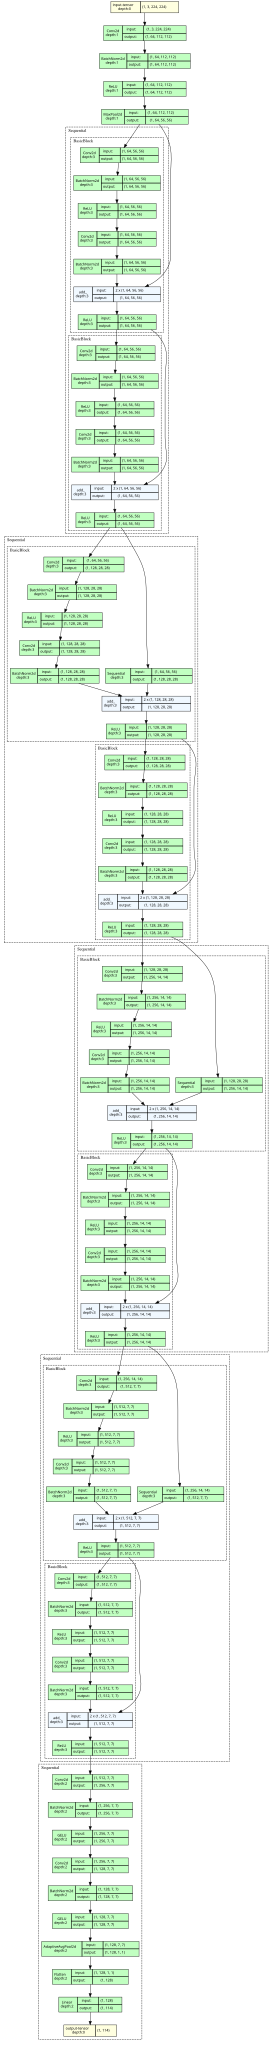

In [ ]:
from torchview import draw_graph

# Rajzolás – teljes modell
draw_graph(
    model,
    input_size=(1, 3, 224, 224),
    expand_nested=True,
    device='cuda'
).visual_graph

🔸 Csak a fej vizualizálása (model.head)

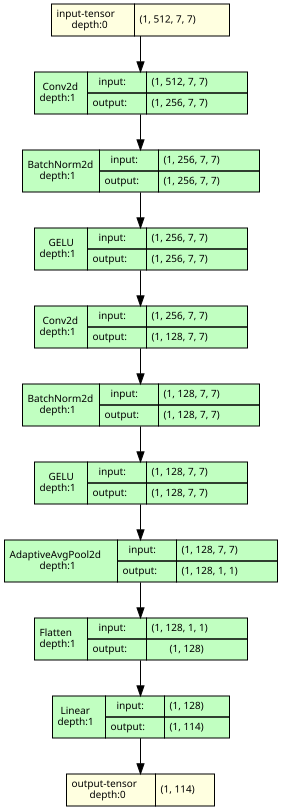

In [ ]:
draw_graph(
    model.head,
    input_size=(1, 512, 7, 7),   # ResNet18 backbone kimenete
    expand_nested=True,
    device='cuda'
).visual_graph

🚀 Előtanítás nélküli teljesítmény

In [ ]:
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import numpy as np
from tqdm import tqdm
import time

# 🔄 Transzformációk (ugyanaz, mint eddig)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# 📁 Teszthalmaz betöltése
test_dir = "/content/imagenet_splitted_db/test"
test_dataset = ImageFolder(test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

# ✅ Használt osztályok (fontos a mapping-hez)
class_names = test_dataset.classes
num_classes = len(class_names)

In [ ]:
model.eval()
e_all_preds, e_all_labels, e_all_probs = [], [], []

e_start_time = time.time()

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="🔍 tesztelés"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        e_all_preds.extend(preds.cpu().numpy())
        e_all_labels.extend(labels.cpu().numpy())
        e_all_probs.extend(probs.cpu().numpy())

e_inference_time_baseline = time.time() - e_start_time


🔍 tesztelés: 100%|██████████| 284/284 [00:17<00:00, 15.88it/s]


In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    top_k_accuracy_score, confusion_matrix, classification_report
)

def evaluate_metrics(y_true, y_pred, y_probs, model_name, inference_time):
    top1 = accuracy_score(y_true, y_pred)
    top5 = top_k_accuracy_score(y_true, y_probs, k=5, labels=range(len(class_names)))
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print(f"\n🔍 Vizsgálat eredményei ({model_name} – tanítás nélkül):")
    print(f"✅ Top-1 Accuracy:  {top1:.4f}")
    print(f"✅ Top-5 Accuracy:  {top5:.4f}")
    print(f"🎯 Precision:       {precision:.4f}")
    print(f"🎯 Recall:          {recall:.4f}")
    print(f"🎯 F1-score:        {f1:.4f}")
    print(f"⏱️ Inference time:  {inference_time:.2f} sec")

    return {
        "top1": top1,
        "top5": top5,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "time": inference_time
    }

In [ ]:
metrics_empty = evaluate_metrics(
    np.array(e_all_labels), np.array(e_all_preds), np.array(e_all_probs),
    "Nem tanított verzió", e_inference_time_baseline
)


🔍 Vizsgálat eredményei (Nem tanított verzió – tanítás nélkül):
✅ Top-1 Accuracy:  0.0054
✅ Top-5 Accuracy:  0.0379
🎯 Precision:       0.0026
🎯 Recall:          0.0063
🎯 F1-score:        0.0020
⏱️ Inference time:  17.89 sec


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, cmap="Blues", xticklabels=labels, yticklabels=labels, cbar=True)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

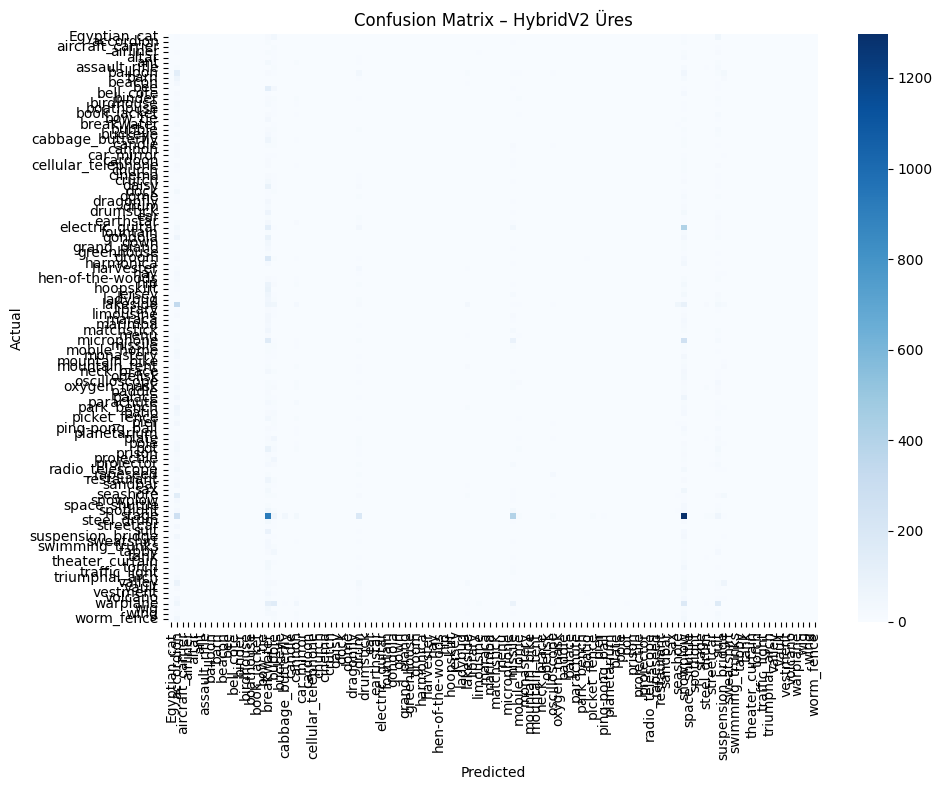

In [ ]:
plot_confusion_matrix(e_all_labels, e_all_preds, class_names, "Confusion Matrix – HybridV2 Üres")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix_pretty(y_true, y_pred, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, normalize='true')

    plt.figure(figsize=(18, 16))  # Nagyobb ábra, hogy elférjen minden
    sns.heatmap(cm, annot=False, cmap='Blues', cbar=True,
                xticklabels=class_names, yticklabels=class_names)

    plt.title(title, fontsize=18)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.ylabel('True Label', fontsize=14)
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.show()


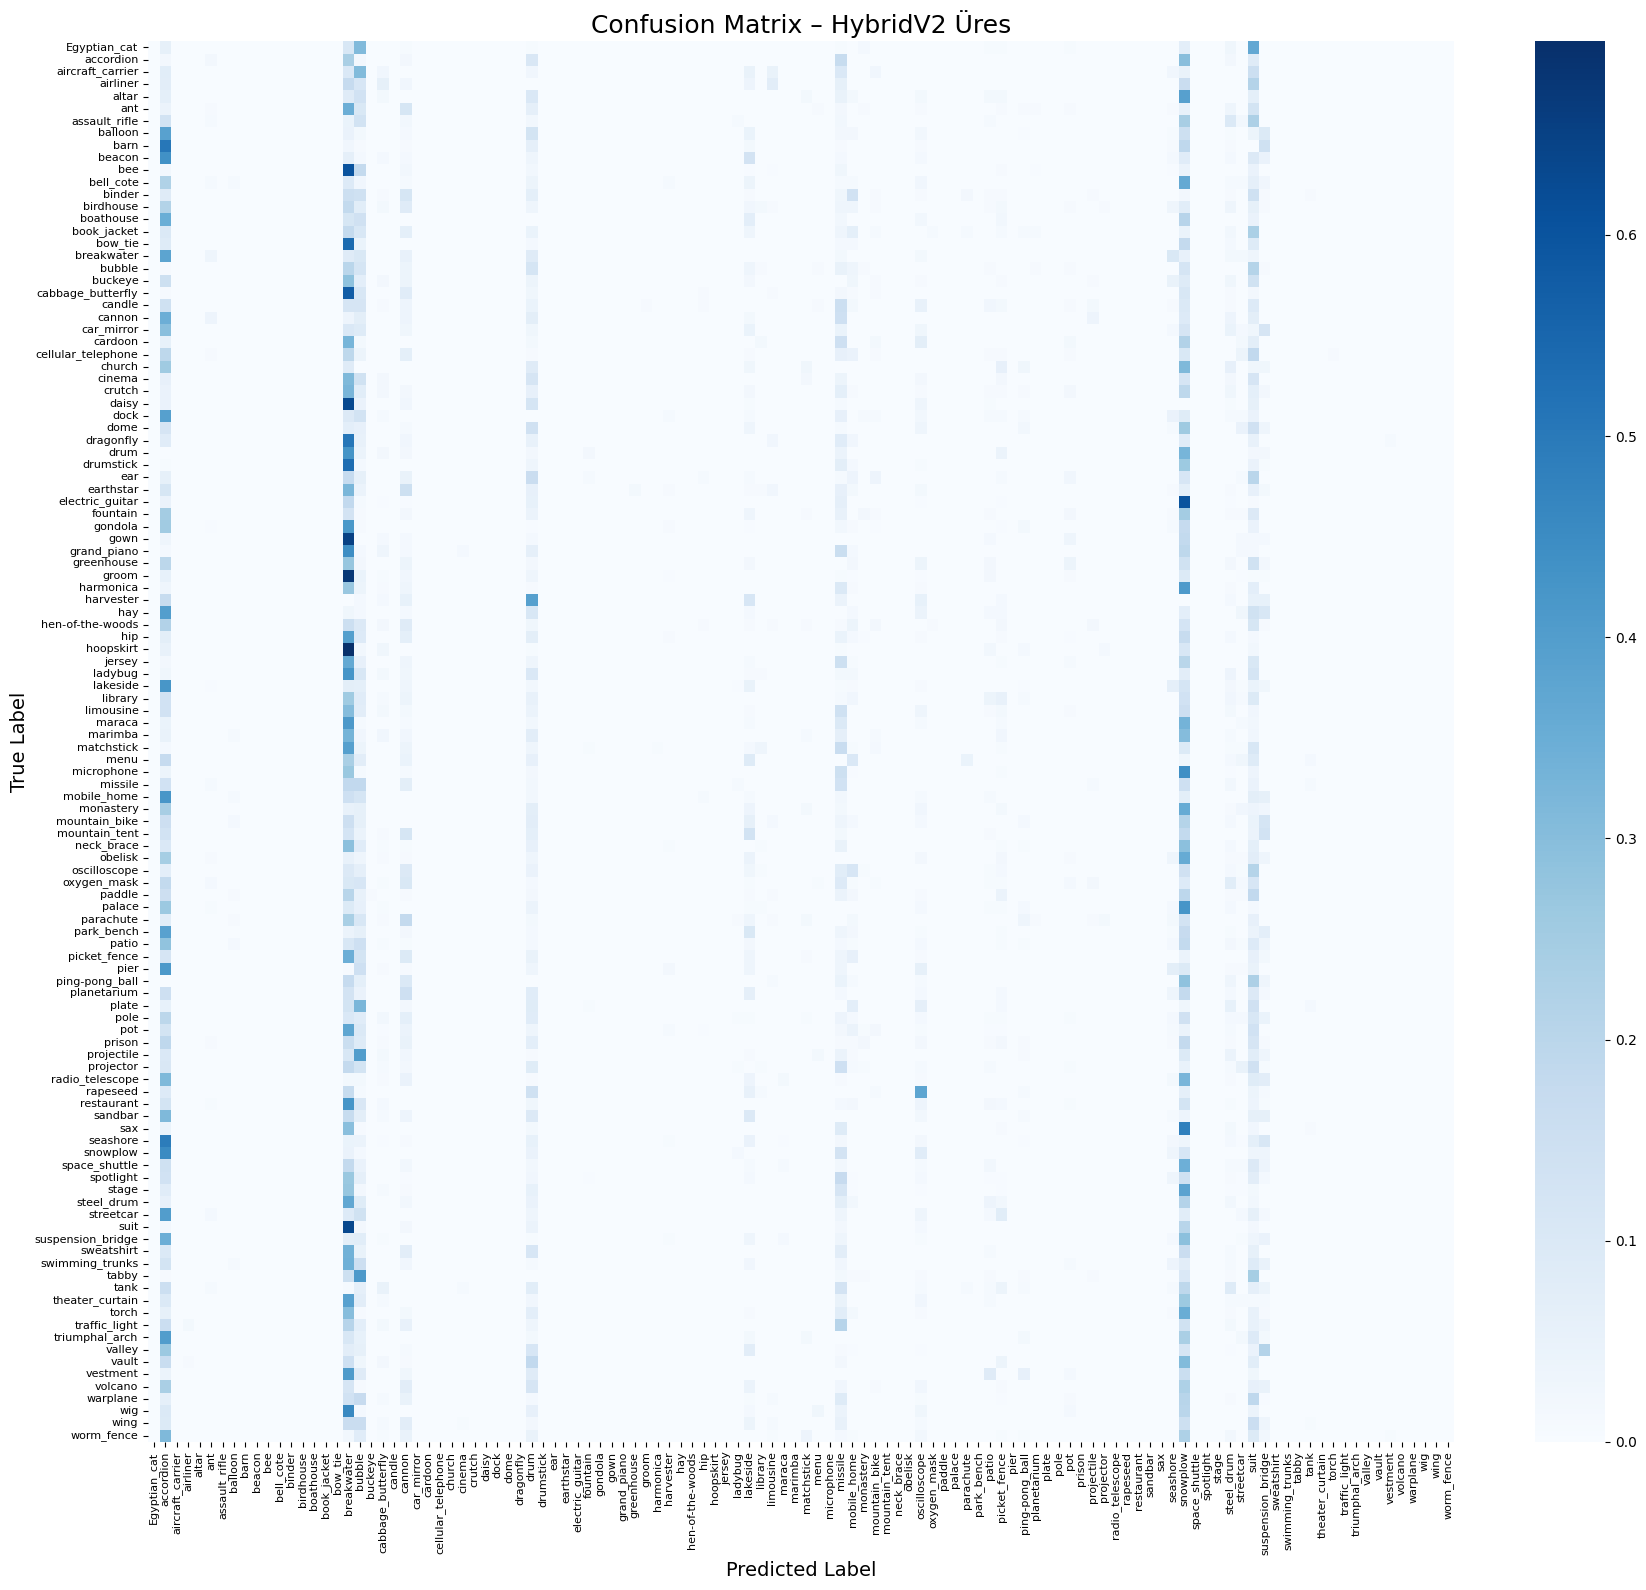

In [ ]:
plot_confusion_matrix_pretty(e_all_labels, e_all_preds, class_names, "Confusion Matrix – HybridV2 Üres")

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

def export_classification_report(y_true, y_pred, class_names, csv_filename):
    report_dict = classification_report(
        y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0
    )
    df = pd.DataFrame(report_dict).transpose()
    df.to_csv(csv_filename, index=True)
    print(f"\n📄 Exportálva: {csv_filename}")
    return df

In [ ]:
print("HybridV2 üres – osztályonkénti metrikák:\n")
e_df_baseline = export_classification_report(e_all_labels, e_all_preds, class_names, "HybridV2_ures.csv")
display(e_df_baseline.head())

HybridV2 üres – osztályonkénti metrikák:


📄 Exportálva: HybridV2_ures.csv


,precision,recall,f1-score,support
Egyptian_cat,0.000000,0.000000,0.000000,145.0
accordion,0.000374,0.021277,0.000735,47.0
aircraft_carrier,0.000000,0.000000,0.000000,39.0
airliner,0.000000,0.000000,0.000000,80.0
altar,0.000000,0.000000,0.000000,59.0


In [ ]:
def print_worst_classes(df, model_name, top_n=10):
    df_filtered = df.iloc[:-3]  # support, accuracy, macro avg sorokat elhagyjuk
    worst = df_filtered.sort_values("f1-score").head(top_n)
    print(f"\n📉 {model_name} – Top {top_n} leggyengébb osztály (F1-score alapján):\n")
    display(worst[["precision", "recall", "f1-score"]])

In [ ]:
print_worst_classes(e_df_baseline, "HybridV2 Üres")


📉 HybridV2 Üres – Top 10 leggyengébb osztály (F1-score alapján):



,precision,recall,f1-score
Egyptian_cat,0.0,0.0,0.0
aircraft_carrier,0.0,0.0,0.0
airliner,0.0,0.0,0.0
altar,0.0,0.0,0.0
balloon,0.0,0.0,0.0
assault_rifle,0.0,0.0,0.0
beacon,0.0,0.0,0.0
barn,0.0,0.0,0.0
binder,0.0,0.0,0.0
birdhouse,0.0,0.0,0.0


In [ ]:
# --- GPU memóriahasználat ---
gpu_mem_allocated = torch.cuda.memory_allocated() / (1024 ** 3)
gpu_mem_reserved = torch.cuda.memory_reserved() / (1024 ** 3)

print(f"💾 GPU memória (lefoglalt): {gpu_mem_reserved:.2f} GB")
print(f"💾 GPU memória (használt):  {gpu_mem_allocated:.2f} GB")

💾 GPU memória (lefoglalt): 0.73 GB
💾 GPU memória (használt):  0.09 GB


---

HybridV2 Teljes tanítás

---

In [ ]:
f_model_a = ResNet18HybridV2Head(num_classes=114).to(device)

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# --- 📦 Könyvtárak ---
root_dir = "/content/imagenet_splitted_db"
batch_size = 64
image_size = 224

# --- 🧪 Transzformációk ---
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet statisztikák
                         std=[0.229, 0.224, 0.225])
])

# --- 📚 Datasetek betöltése ---
train_dataset = datasets.ImageFolder(root=f"{root_dir}/train", transform=transform)
val_dataset   = datasets.ImageFolder(root=f"{root_dir}/val", transform=transform)
test_dataset  = datasets.ImageFolder(root=f"{root_dir}/test", transform=transform)

# --- 🚚 Adatbetöltők ---
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# --- 📌 Osztálynevek elmentése ha szükséges ---
class_names = train_dataset.classes
num_classes = len(class_names)
print(f"📊 Osztályok száma: {num_classes}")


📊 Osztályok száma: 114


In [ ]:
from torch.optim import Adam
from torch.nn import CrossEntropyLoss
from tqdm import tqdm

import matplotlib.pyplot as plt

def train_model(model, model_name, num_epochs=10, plot_results=True):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    train_loss_hist, val_loss_hist = [], []
    train_acc_hist, val_acc_hist = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in tqdm(train_loader, desc=f"[{model_name}] Epoch {epoch+1}/{num_epochs} - train"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total
        train_loss_hist.append(train_loss)
        train_acc_hist.append(train_acc)

        # Validáció
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc=f"[{model_name}] Epoch {epoch+1}/{num_epochs} - val"):
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss /= total
        val_acc = correct / total
        val_loss_hist.append(val_loss)
        val_acc_hist.append(val_acc)

        print(f"📊 [{model_name}] Epoch {epoch+1}: Train loss={train_loss:.4f}, acc={train_acc:.4f} | Val loss={val_loss:.4f}, acc={val_acc:.4f}")

    # --- 🎨 Tanulási görbék ---
    if plot_results:
        plt.figure(figsize=(12, 4))

        # Loss
        plt.subplot(1, 2, 1)
        plt.plot(train_loss_hist, label="Train Loss")
        plt.plot(val_loss_hist, label="Val Loss")
        plt.title(f"{model_name} – Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True)

        # Accuracy
        plt.subplot(1, 2, 2)
        plt.plot(train_acc_hist, label="Train Acc")
        plt.plot(val_acc_hist, label="Val Acc")
        plt.title(f"{model_name} – Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

    return model, train_loss_hist, val_loss_hist, train_acc_hist, val_acc_hist

[HybridV2 Full] Epoch 1/10 - val: 100%|██████████| 282/282 [00:16<00:00, 16.96it/s]


📊 [HybridV2 Full] Epoch 1: Train loss=2.0300, acc=0.5489 | Val loss=1.4556, acc=0.6270


[HybridV2 Full] Epoch 2/10 - val: 100%|██████████| 282/282 [00:16<00:00, 17.57it/s]


📊 [HybridV2 Full] Epoch 2: Train loss=1.1967, acc=0.6915 | Val loss=1.2160, acc=0.6762


[HybridV2 Full] Epoch 3/10 - val: 100%|██████████| 282/282 [00:16<00:00, 17.47it/s]


...

📊 [HybridV2 Full] Epoch 8: Train loss=0.1848, acc=0.9494 | Val loss=1.2806, acc=0.7229


[HybridV2 Full] Epoch 9/10 - val: 100%|██████████| 282/282 [00:15<00:00, 17.97it/s]


📊 [HybridV2 Full] Epoch 9: Train loss=0.1627, acc=0.9544 | Val loss=1.3337, acc=0.7269


[HybridV2 Full] Epoch 10/10 - val: 100%|██████████| 282/282 [00:15<00:00, 17.97it/s]


📊 [HybridV2 Full] Epoch 10: Train loss=0.1413, acc=0.9605 | Val loss=1.3854, acc=0.7265


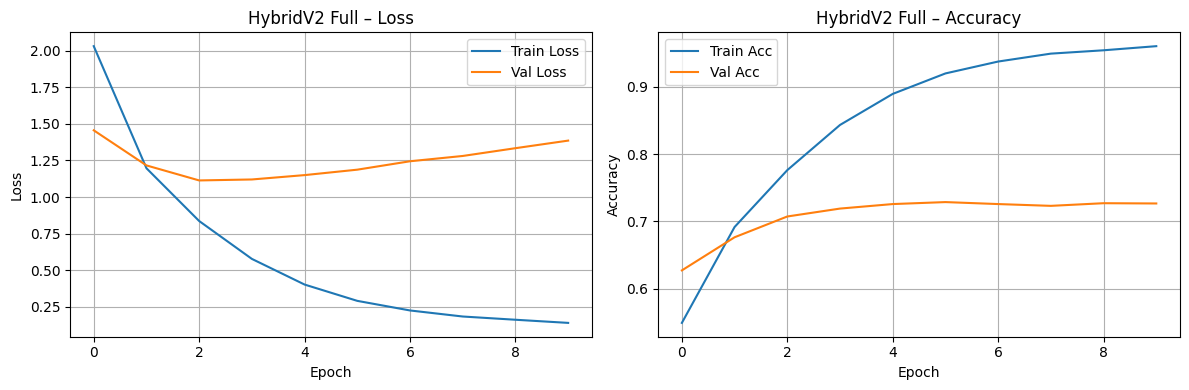

In [ ]:
# 🚀 Tanítás: Baseline
f_model, f_loss_baseline, f_val_loss_baseline, f_acc_baseline, f_val_acc_baseline = train_model(
    f_model_a, model_name="HybridV2 Full", num_epochs=10
)

In [ ]:
# --- Modellmentés (állapotdict mentése) ---
save_dir = "trained_models"
os.makedirs(save_dir, exist_ok=True)

torch.save(f_model.state_dict(), f"{save_dir}/resnet18_HybridV2_Full.pth")
print("✅ Modell sikeresen elmentve:")
print(f"📦 {save_dir}/resnet18_HybridV2_Full.pth")

✅ Modell sikeresen elmentve:
📦 trained_models/resnet18_HybridV2_Full.pth


In [ ]:
f_model.eval()
f_all_preds, f_all_labels, f_all_probs = [], [], []

f_start_time = time.time()

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="🔍 Baseline modell – tesztelés"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = f_model(inputs)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        f_all_preds.extend(preds.cpu().numpy())
        f_all_labels.extend(labels.cpu().numpy())
        f_all_probs.extend(probs.cpu().numpy())

f_inference_time_baseline = time.time() - f_start_time

🔍 Baseline modell – tesztelés: 100%|██████████| 284/284 [00:15<00:00, 18.19it/s]


In [ ]:
f_metrics_baseline = evaluate_metrics(
    np.array(f_all_labels), np.array(f_all_preds), np.array(f_all_probs),
    "HybridV2 Full", f_inference_time_baseline
)


🔍 Vizsgálat eredményei (HybridV2 Full – tanítás nélkül):
✅ Top-1 Accuracy:  0.7236
✅ Top-5 Accuracy:  0.9011
🎯 Precision:       0.6669
🎯 Recall:          0.6391
🎯 F1-score:        0.6469
⏱️ Inference time:  15.62 sec


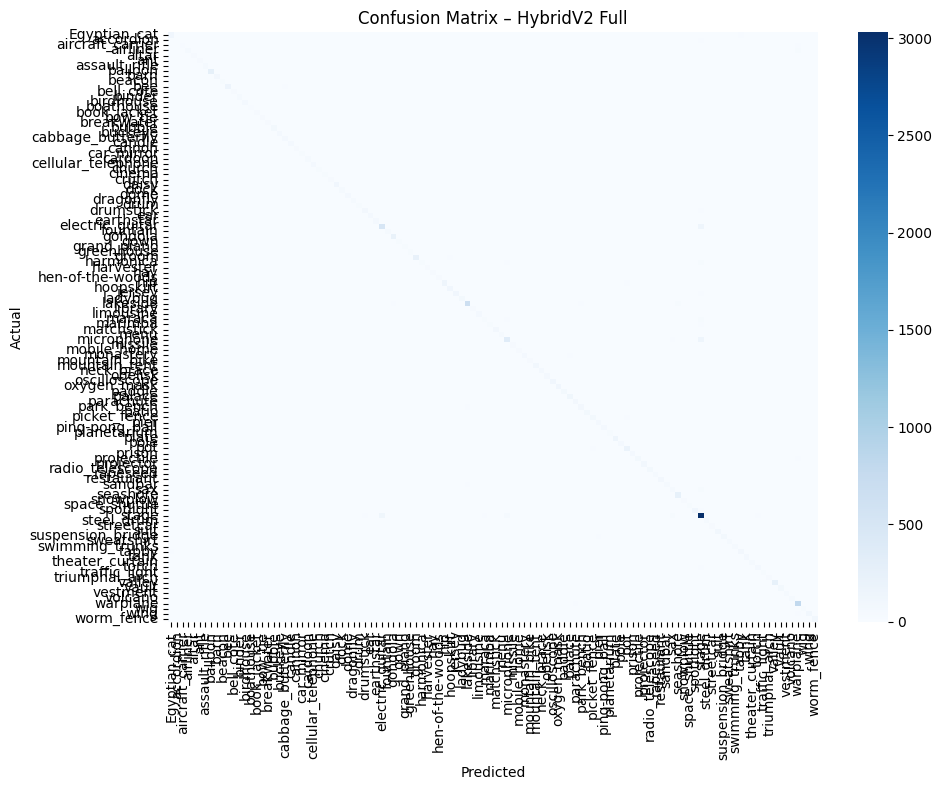

In [ ]:
plot_confusion_matrix(f_all_labels, f_all_preds, class_names, "Confusion Matrix – HybridV2 Full")

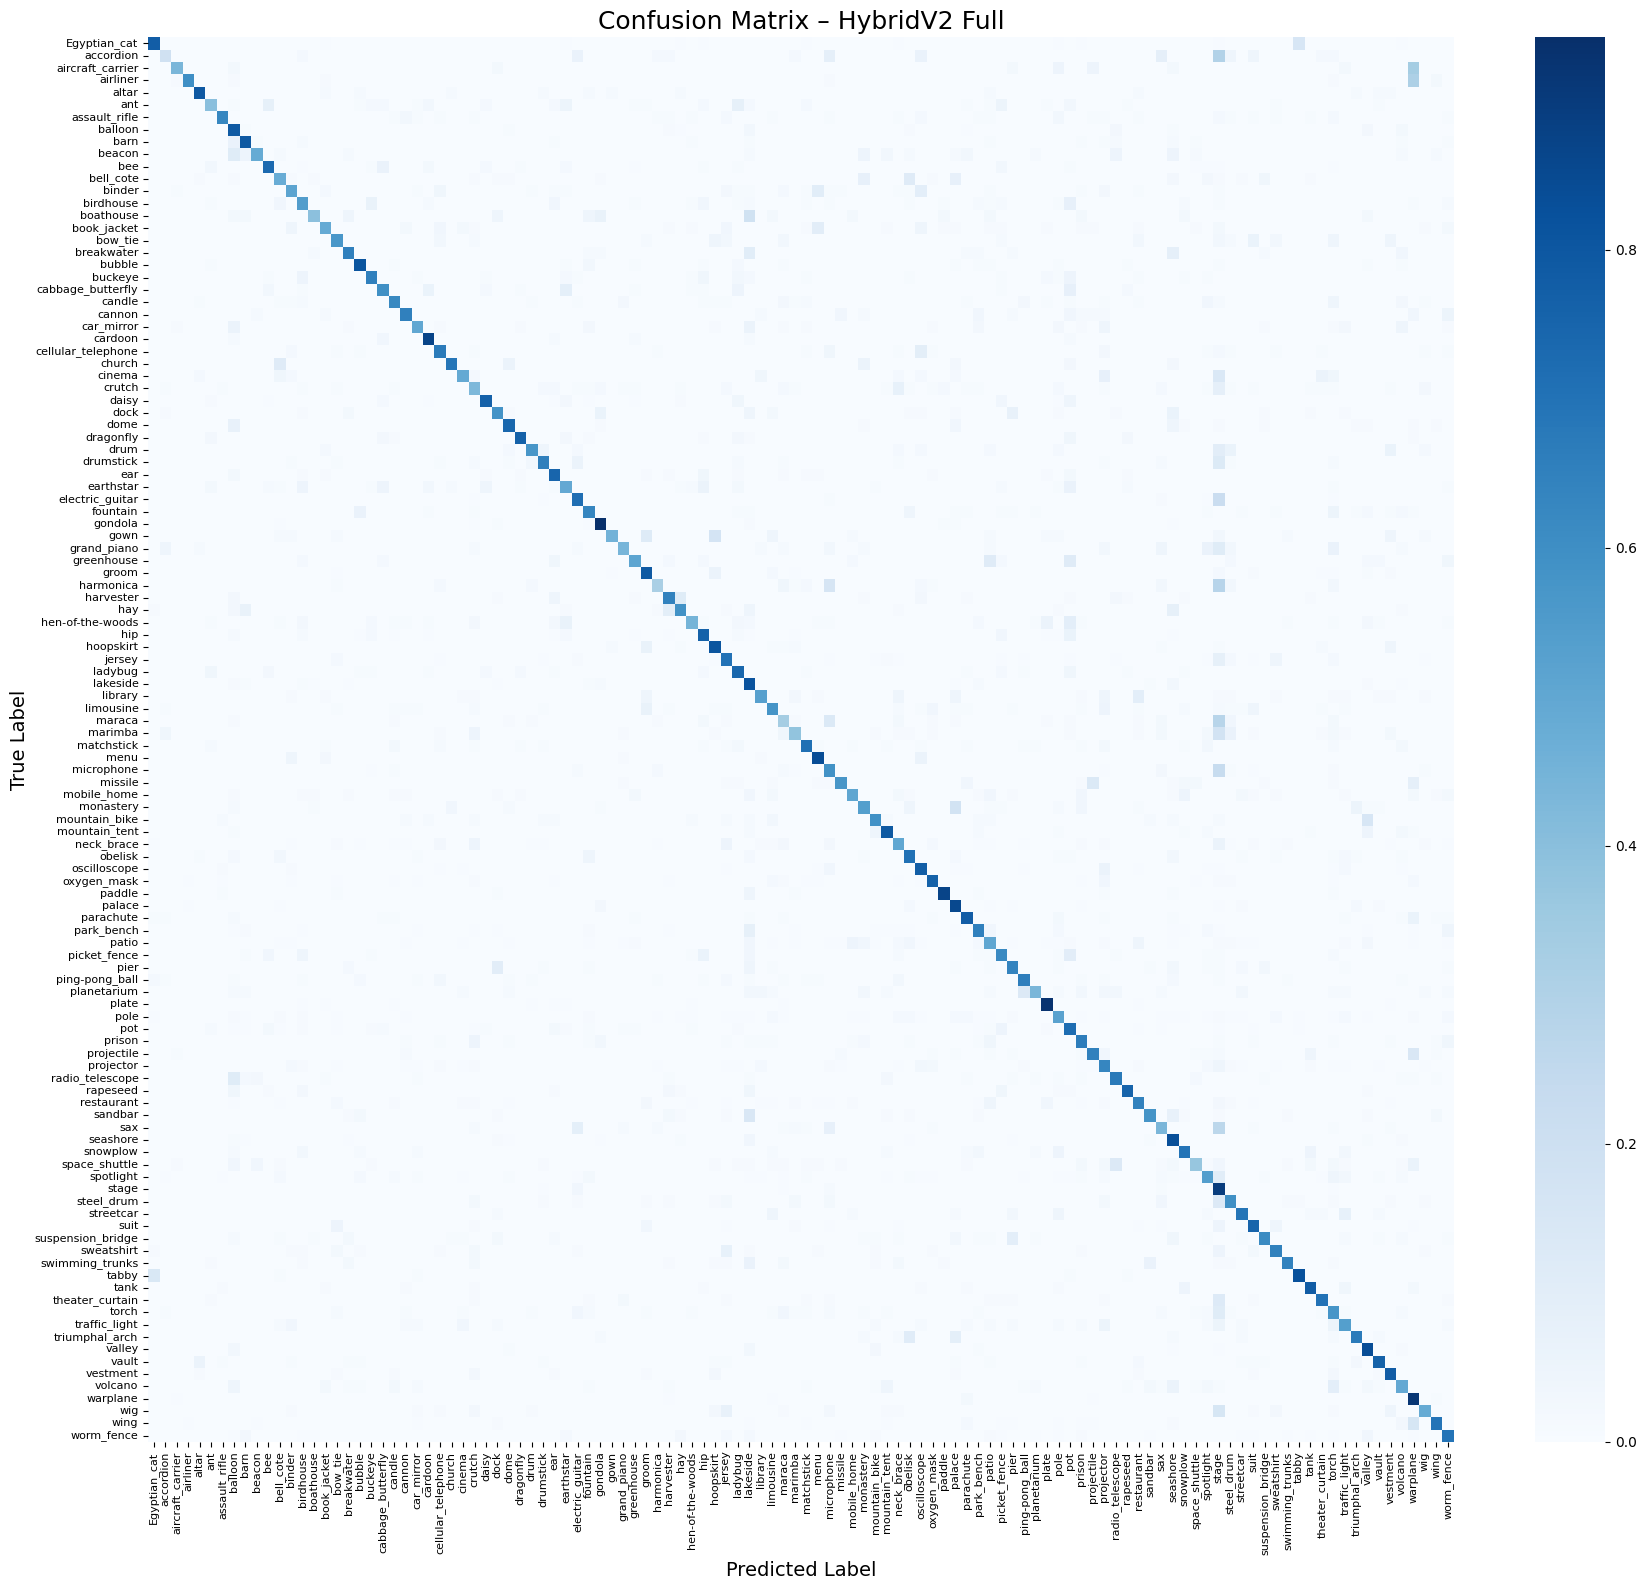

In [ ]:
plot_confusion_matrix_pretty(f_all_labels, f_all_preds, class_names, "Confusion Matrix – HybridV2 Full")

In [ ]:
print("HybridV2 üres – osztályonkénti metrikák:\n")
f_df_baseline = export_classification_report(f_all_labels, f_all_preds, class_names, "HybridV2_full.csv")
display(f_df_baseline.head())

HybridV2 üres – osztályonkénti metrikák:


📄 Exportálva: HybridV2_full.csv


,precision,recall,f1-score,support
Egyptian_cat,0.830882,0.779310,0.804270,145.0
accordion,0.300000,0.191489,0.233766,47.0
aircraft_carrier,0.607143,0.435897,0.507463,39.0
airliner,0.888889,0.600000,0.716418,80.0
altar,0.796610,0.796610,0.796610,59.0


In [ ]:
print_worst_classes(f_df_baseline, "HybridV2 Üres")


📉 HybridV2 Üres – Top 10 leggyengébb osztály (F1-score alapján):



,precision,recall,f1-score
accordion,0.300000,0.191489,0.233766
maraca,0.312500,0.333333,0.322581
harmonica,0.484848,0.320000,0.385542
sax,0.368421,0.437500,0.400000
crutch,0.387931,0.428571,0.407240
marimba,0.461538,0.379747,0.416667
torch,0.348958,0.577586,0.435065
traffic_light,0.402597,0.534483,0.459259
ant,0.567164,0.400000,0.469136
space_shuttle,0.645833,0.369048,0.469697


In [ ]:
# --- GPU memóriahasználat ---
gpu_mem_allocated = torch.cuda.memory_allocated() / (1024 ** 3)
gpu_mem_reserved = torch.cuda.memory_reserved() / (1024 ** 3)

print(f"💾 GPU memória (lefoglalt): {gpu_mem_reserved:.2f} GB")
print(f"💾 GPU memória (használt):  {gpu_mem_allocated:.2f} GB")

💾 GPU memória (lefoglalt): 2.44 GB
💾 GPU memória (használt):  0.20 GB


---

1K 5K 10K 25K Vizsgálat

---

In [ ]:
# --- 📦 Könyvtárak ---
import os
import random
from collections import defaultdict
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

# --- ⚙️ Alapbeállítások ---
root_dir = "/content/imagenet_splitted_db"
batch_size = 64
image_size = 224
subset_sizes = [1000, 5000, 10000, 25000]

# --- 🧪 Transzformációk ---
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet statisztikák
                         std=[0.229, 0.224, 0.225])
])

# --- 📚 Datasetek betöltése ---
train_dataset_full = datasets.ImageFolder(os.path.join(root_dir, "train"), transform=transform)
val_dataset         = datasets.ImageFolder(os.path.join(root_dir, "val"), transform=transform)
test_dataset        = datasets.ImageFolder(os.path.join(root_dir, "test"), transform=transform)

# --- 🧪 Stratifikált részhalmaz létrehozó függvény ---
def stratified_subset(dataset, total_images):
    class_indices = defaultdict(list)
    for idx, (_, label) in enumerate(dataset.samples):
        class_indices[label].append(idx)

    total_classes = len(class_indices)
    per_class = total_images // total_classes
    selected_indices = []

    for cls, indices in class_indices.items():
        selected = random.sample(indices, min(per_class, len(indices)))
        selected_indices.extend(selected)

    print(f"📦 Részhalmaz méret: {len(selected_indices)} kép")
    return Subset(dataset, selected_indices)

# --- 🧪 Részhalmazok generálása ---
train_subsets = {f"{size}": stratified_subset(train_dataset_full, size) for size in subset_sizes}

# --- 🚚 Adatbetöltők ---
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# --- 📌 Osztálynevek és osztályszám ---
class_names = train_dataset_full.classes
num_classes = len(class_names)
print(f"📊 Osztályok száma: {num_classes}")


📦 Részhalmaz méret: 912 kép
📦 Részhalmaz méret: 4902 kép
📦 Részhalmaz méret: 9918 kép
📦 Részhalmaz méret: 24966 kép
📊 Osztályok száma: 114


In [ ]:
from torch.utils.data import DataLoader
import torch.nn as nn
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

def train_model_on_subset(model, model_name, train_dataset_subset, num_epochs=10, plot_results=True):
    """
    Modell tanítása egy adott részhalmazon.
    A modell, a modell neve és a részhalmaz külön adható meg.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    # 🔁 Betöltő a részhalmazra
    train_loader = DataLoader(train_dataset_subset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)

    train_loss_hist, val_loss_hist = [], []
    train_acc_hist, val_acc_hist = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in tqdm(train_loader, desc=f"[{model_name}] Epoch {epoch+1}/{num_epochs} - train"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total
        train_loss_hist.append(train_loss)
        train_acc_hist.append(train_acc)

        # --- 🔎 Validáció ---
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc=f"[{model_name}] Epoch {epoch+1}/{num_epochs} - val"):
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss /= total
        val_acc = correct / total
        val_loss_hist.append(val_loss)
        val_acc_hist.append(val_acc)

        print(f"📊 [{model_name}] Epoch {epoch+1}: Train loss={train_loss:.4f}, acc={train_acc:.4f} | Val loss={val_loss:.4f}, acc={val_acc:.4f}")

    # --- 🎨 Tanulási görbék ---
    if plot_results:
        plt.figure(figsize=(12, 4))

        # Loss
        plt.subplot(1, 2, 1)
        plt.plot(train_loss_hist, label="Train Loss")
        plt.plot(val_loss_hist, label="Val Loss")
        plt.title(f"{model_name} – Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True)

        # Accuracy
        plt.subplot(1, 2, 2)
        plt.plot(train_acc_hist, label="Train Acc")
        plt.plot(val_acc_hist, label="Val Acc")
        plt.title(f"{model_name} – Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

    return model, train_loss_hist, val_loss_hist, train_acc_hist, val_acc_hist


---
1k

---

[ResNet18-Hybrid-1k] Epoch 1/10 - val: 100%|██████████| 282/282 [00:15<00:00, 17.83it/s]


📊 [ResNet18-Hybrid-1k] Epoch 1: Train loss=4.6301, acc=0.0526 | Val loss=4.5241, acc=0.1110


[ResNet18-Hybrid-1k] Epoch 2/10 - val: 100%|██████████| 282/282 [00:15<00:00, 18.07it/s]


📊 [ResNet18-Hybrid-1k] Epoch 2: Train loss=3.9303, acc=0.4792 | Val loss=4.3123, acc=0.1497


[ResNet18-Hybrid-1k] Epoch 3/10 - val: 100%|██████████| 282/282 [00:15<00:00, 18.19it/s]


...

📊 [ResNet18-Hybrid-1k] Epoch 8: Train loss=2.2559, acc=0.9868 | Val loss=4.1284, acc=0.2813


[ResNet18-Hybrid-1k] Epoch 9/10 - val: 100%|██████████| 282/282 [00:15<00:00, 18.02it/s]


📊 [ResNet18-Hybrid-1k] Epoch 9: Train loss=2.0754, acc=0.9934 | Val loss=4.1285, acc=0.2754


[ResNet18-Hybrid-1k] Epoch 10/10 - val: 100%|██████████| 282/282 [00:15<00:00, 18.04it/s]


📊 [ResNet18-Hybrid-1k] Epoch 10: Train loss=1.9043, acc=0.9956 | Val loss=4.1095, acc=0.3063


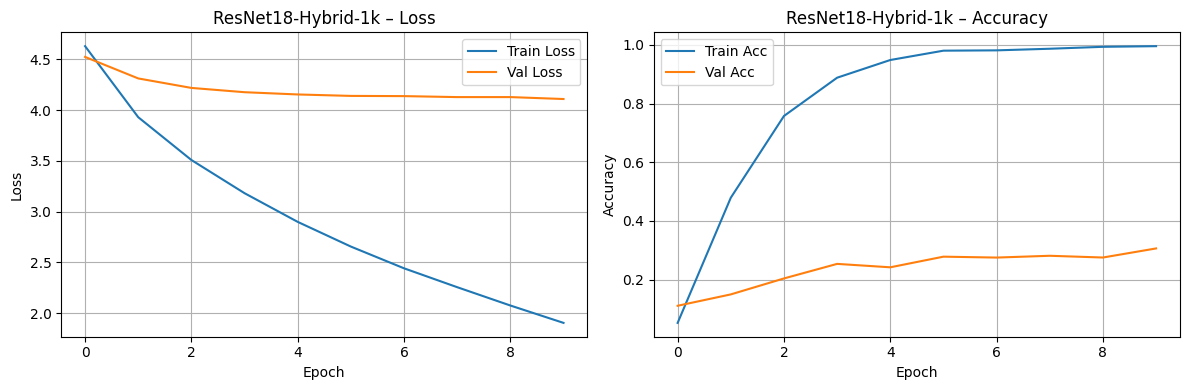

In [ ]:
h1_model_a = ResNet18HybridV2Head(num_classes=114).to(device)
subset_1k = train_subsets["1000"]
h1_model, h1_train_loss_hist, h1_val_loss_hist, h1_train_acc_hist, h1_val_acc_hist = train_model_on_subset(h1_model_a, "ResNet18-Hybrid-1k", subset_1k, num_epochs=10, plot_results=True)


In [ ]:
h1_model.eval()
h1_all_preds, h1_all_labels, h1_all_probs = [], [], []

h1_start_time = time.time()

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="🔍 Hybrid modell 1k – tesztelés"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = h1_model(inputs)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        h1_all_preds.extend(preds.cpu().numpy())
        h1_all_labels.extend(labels.cpu().numpy())
        h1_all_probs.extend(probs.cpu().numpy())

h1_inference_time_baseline = time.time() - h1_start_time

🔍 Hybrid modell 1k – tesztelés: 100%|██████████| 284/284 [00:15<00:00, 17.95it/s]


In [ ]:
h1_metrics_baseline = evaluate_metrics(
    np.array(h1_all_labels), np.array(h1_all_preds), np.array(h1_all_probs),
    "ResNet18 + Hybrid fej 1k", h1_inference_time_baseline
)


🔍 Vizsgálat eredményei (ResNet18 + Hybrid fej 1k – tanítás nélkül):
✅ Top-1 Accuracy:  0.3061
✅ Top-5 Accuracy:  0.5271
🎯 Precision:       0.2641
🎯 Recall:          0.2833
🎯 F1-score:        0.2441
⏱️ Inference time:  15.83 sec


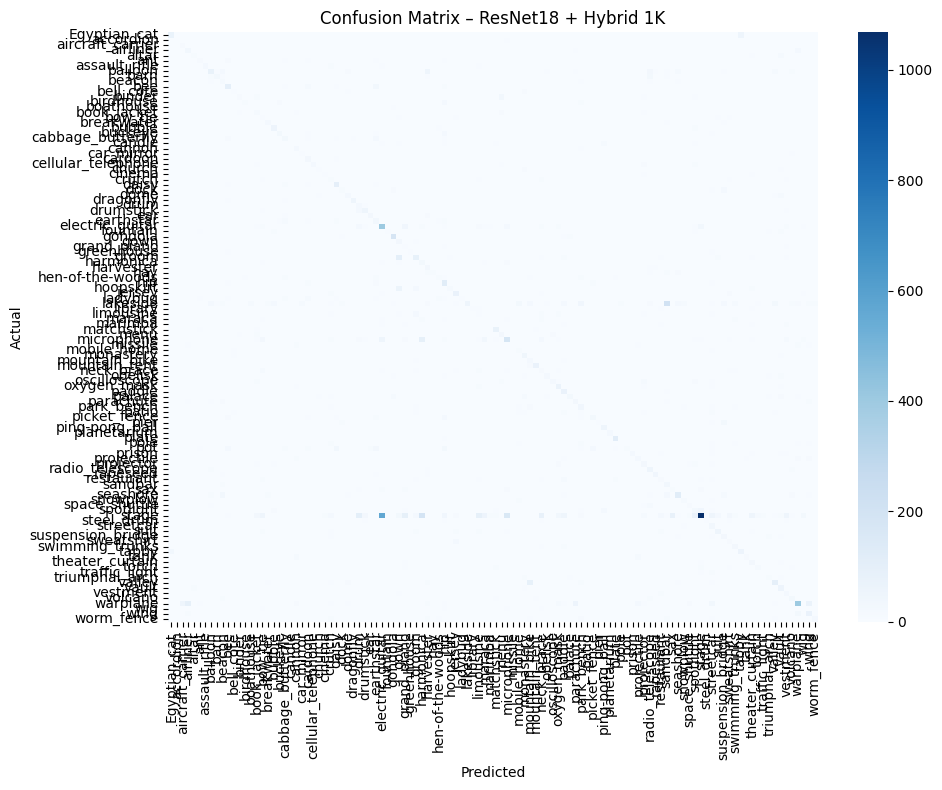

In [ ]:
plot_confusion_matrix(h1_all_labels, h1_all_preds, class_names, "Confusion Matrix – ResNet18 + Hybrid 1K")

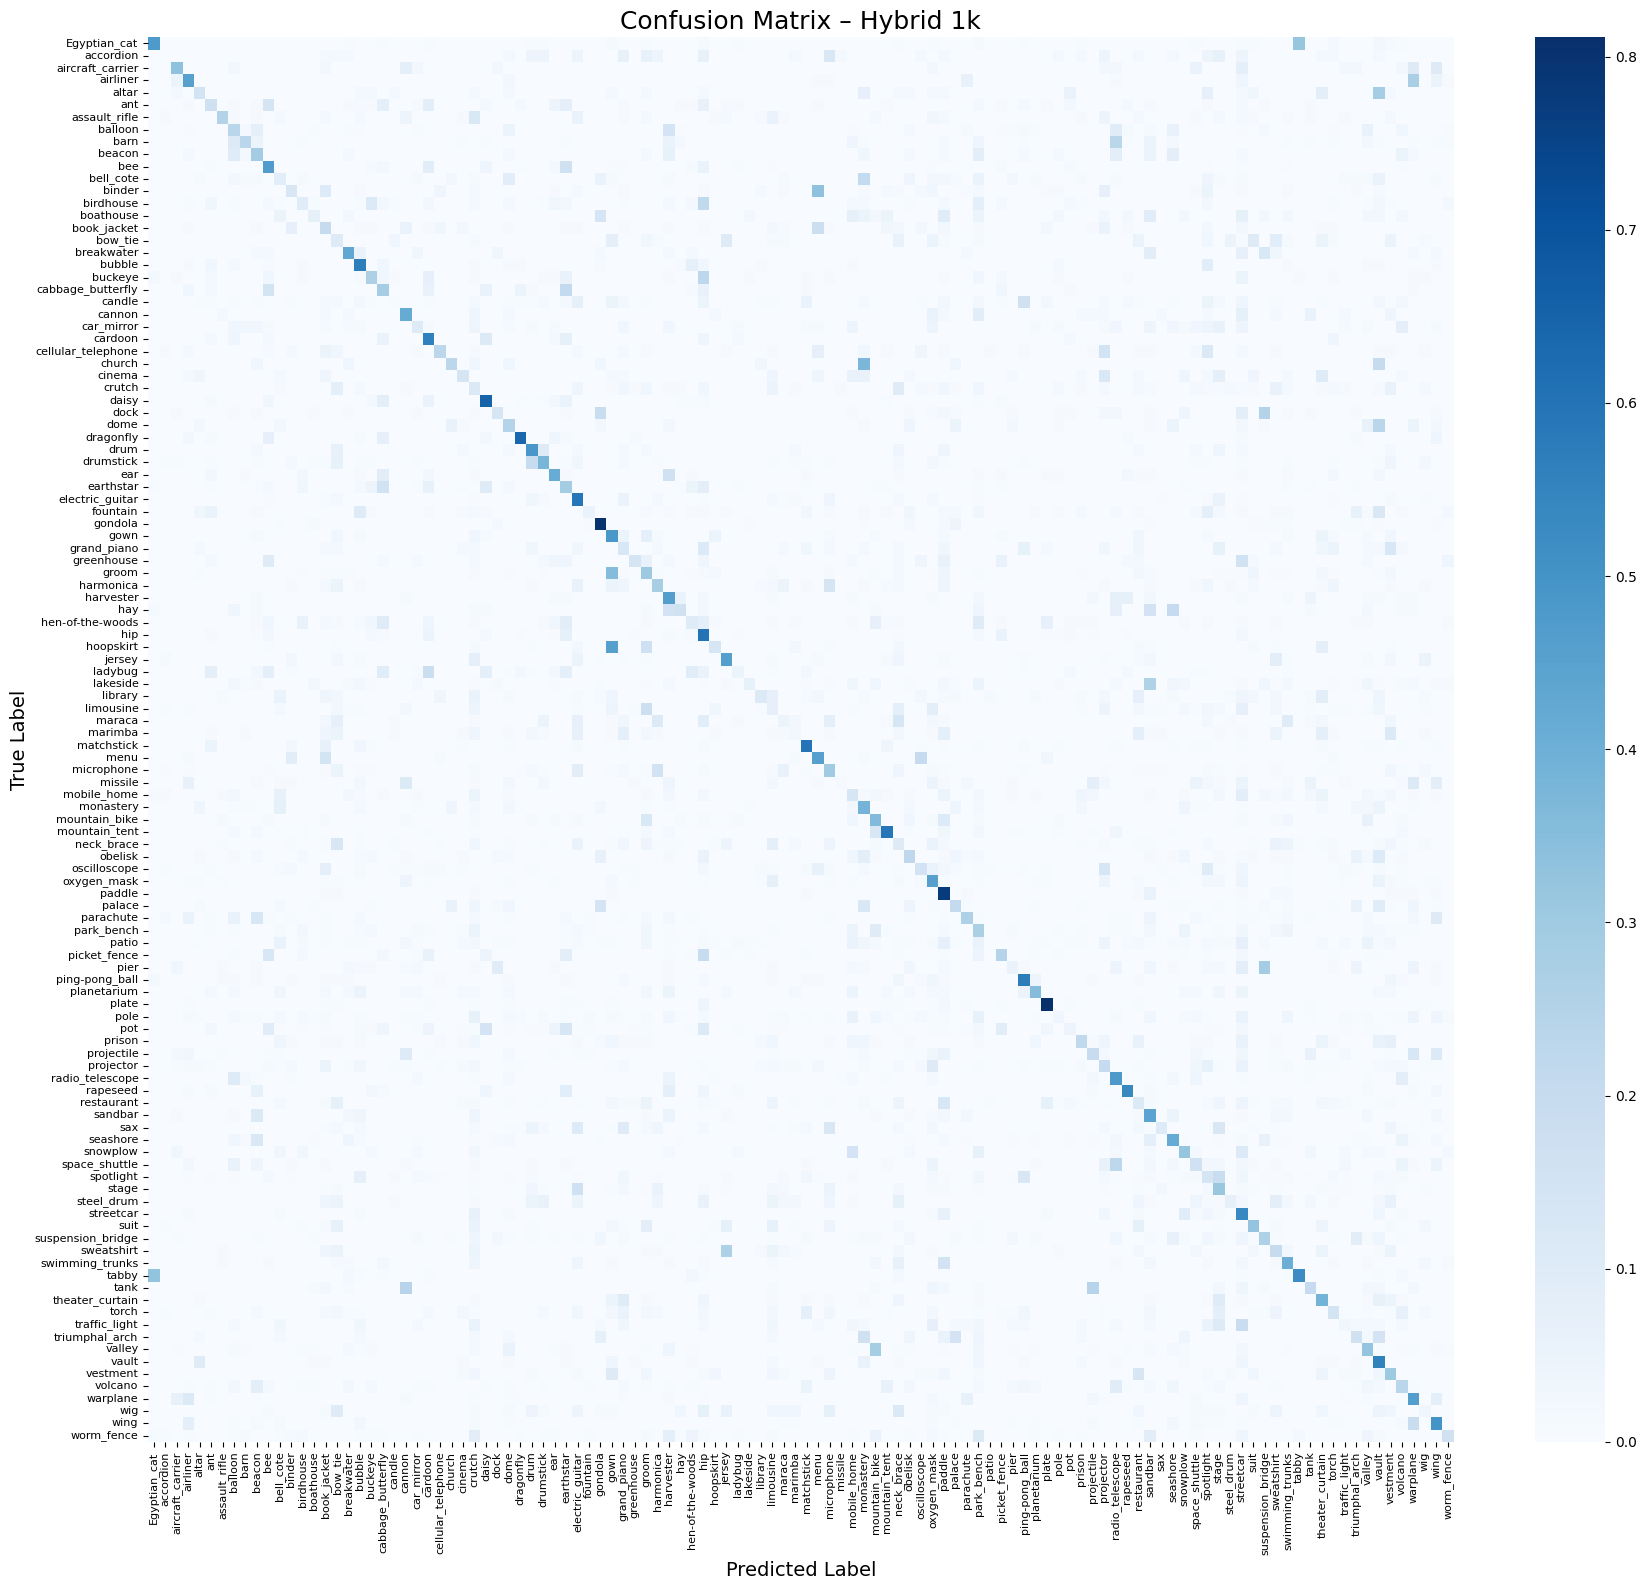

In [ ]:
plot_confusion_matrix_pretty(h1_all_labels, h1_all_preds, class_names, "Confusion Matrix – Hybrid 1k")

In [ ]:
print("📋 Hybrid modell 1k – osztályonkénti metrikák:\n")
h1_df_baseline = export_classification_report(h1_all_labels, h1_all_preds, class_names, "stage_3_resnet18_hybrid_1k")
display(h1_df_baseline.head())

📋 Hybrid modell 1k – osztályonkénti metrikák:


📄 Exportálva: stage_3_resnet18_hybrid_1k


,precision,recall,f1-score,support
Egyptian_cat,0.616071,0.475862,0.536965,145.0
accordion,0.000000,0.000000,0.000000,47.0
aircraft_carrier,0.146067,0.333333,0.203125,39.0
airliner,0.188482,0.450000,0.265683,80.0
altar,0.183673,0.152542,0.166667,59.0


In [ ]:
print_worst_classes(h1_df_baseline, "ResNet18 + Hybrid 1k fej")


📉 ResNet18 + Hybrid 1k fej – Top 10 leggyengébb osztály (F1-score alapján):



,precision,recall,f1-score
accordion,0.000000,0.000000,0.000000
patio,0.000000,0.000000,0.000000
candle,0.071429,0.009009,0.016000
missile,0.125000,0.012195,0.022222
wig,0.024390,0.028571,0.026316
marimba,0.044444,0.025316,0.032258
maraca,0.031250,0.044444,0.036697
traffic_light,0.042553,0.034483,0.038095
pole,0.090909,0.029412,0.044444
limousine,0.033613,0.067227,0.044818


In [ ]:
# --- GPU memóriahasználat ---
gpu_mem_allocated = torch.cuda.memory_allocated() / (1024 ** 3)
gpu_mem_reserved = torch.cuda.memory_reserved() / (1024 ** 3)

print(f"💾 GPU memória (lefoglalt): {gpu_mem_reserved:.2f} GB")
print(f"💾 GPU memória (használt):  {gpu_mem_allocated:.2f} GB")

💾 GPU memória (lefoglalt): 2.44 GB
💾 GPU memória (használt):  0.29 GB


---

5k

---

[ResNet18-Hybrid-5k] Epoch 1/10 - val: 100%|██████████| 282/282 [00:15<00:00, 18.15it/s]


📊 [ResNet18-Hybrid-5k] Epoch 1: Train loss=4.1877, acc=0.1707 | Val loss=3.6957, acc=0.2797


[ResNet18-Hybrid-5k] Epoch 2/10 - val: 100%|██████████| 282/282 [00:15<00:00, 17.88it/s]


📊 [ResNet18-Hybrid-5k] Epoch 2: Train loss=3.4674, acc=0.3978 | Val loss=3.4948, acc=0.3527


[ResNet18-Hybrid-5k] Epoch 3/10 - val: 100%|██████████| 282/282 [00:15<00:00, 17.92it/s]


...

📊 [ResNet18-Hybrid-5k] Epoch 8: Train loss=0.8897, acc=0.9908 | Val loss=3.0145, acc=0.4073


[ResNet18-Hybrid-5k] Epoch 9/10 - val: 100%|██████████| 282/282 [00:15<00:00, 18.11it/s]


📊 [ResNet18-Hybrid-5k] Epoch 9: Train loss=0.6601, acc=0.9949 | Val loss=3.0399, acc=0.4020


[ResNet18-Hybrid-5k] Epoch 10/10 - val: 100%|██████████| 282/282 [00:16<00:00, 17.53it/s]


📊 [ResNet18-Hybrid-5k] Epoch 10: Train loss=0.4827, acc=0.9978 | Val loss=2.9416, acc=0.4106


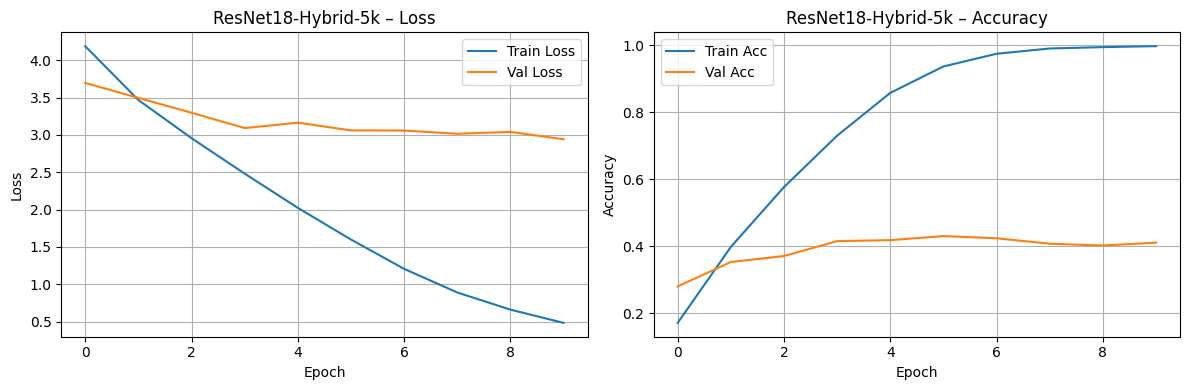

In [ ]:
h5_model_a = ResNet18HybridV2Head(num_classes=114).to(device)
subset_5k = train_subsets["5000"]
h5_model, h5_train_loss_hist, h5_val_loss_hist, h5_train_acc_hist, h5_val_acc_hist = train_model_on_subset(h5_model_a, "ResNet18-Hybrid-5k", subset_5k, num_epochs=10, plot_results=True)

In [ ]:
h5_model.eval()
h5_all_preds, h5_all_labels, h5_all_probs = [], [], []

h5_start_time = time.time()

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="🔍 Hybrid modell 1k – tesztelés"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = h5_model(inputs)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        h5_all_preds.extend(preds.cpu().numpy())
        h5_all_labels.extend(labels.cpu().numpy())
        h5_all_probs.extend(probs.cpu().numpy())

h5_inference_time_baseline = time.time() - h5_start_time

🔍 Hybrid modell 1k – tesztelés: 100%|██████████| 284/284 [00:15<00:00, 18.06it/s]


In [ ]:
h5_metrics_baseline = evaluate_metrics(
    np.array(h5_all_labels), np.array(h5_all_preds), np.array(h5_all_probs),
    "ResNet18 + Hybrid fej 5k", h5_inference_time_baseline
)


🔍 Vizsgálat eredményei (ResNet18 + Hybrid fej 5k – tanítás nélkül):
✅ Top-1 Accuracy:  0.4121
✅ Top-5 Accuracy:  0.6933
🎯 Precision:       0.4068
🎯 Recall:          0.4441
🎯 F1-score:        0.4042
⏱️ Inference time:  15.73 sec


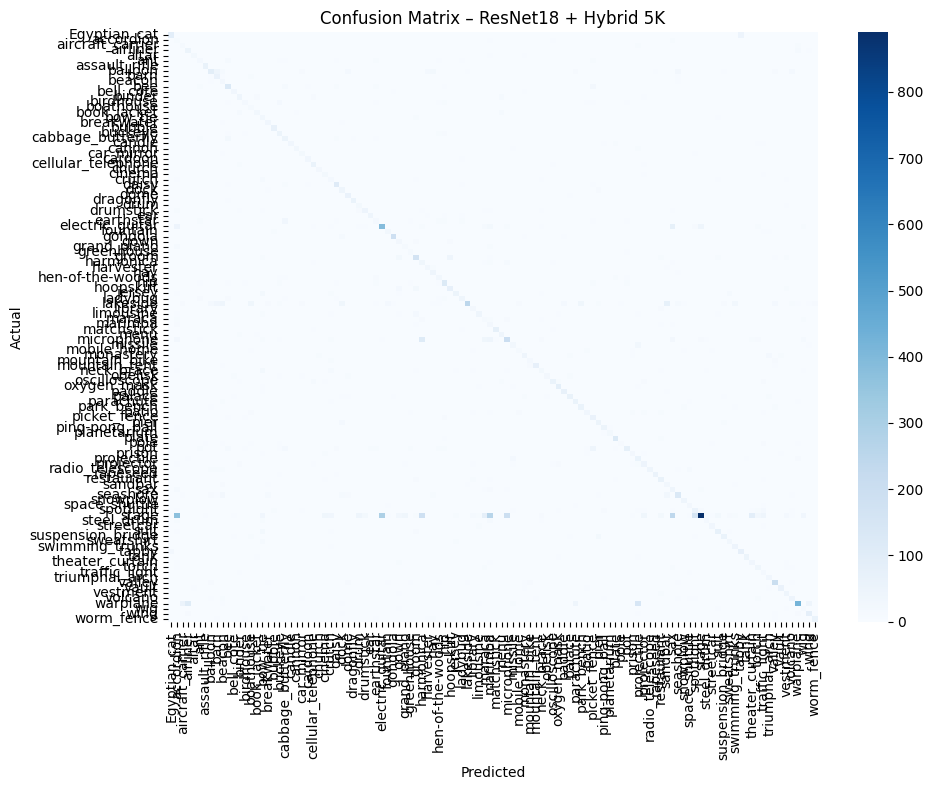

In [ ]:
plot_confusion_matrix(h5_all_labels, h5_all_preds, class_names, "Confusion Matrix – ResNet18 + Hybrid 5K")

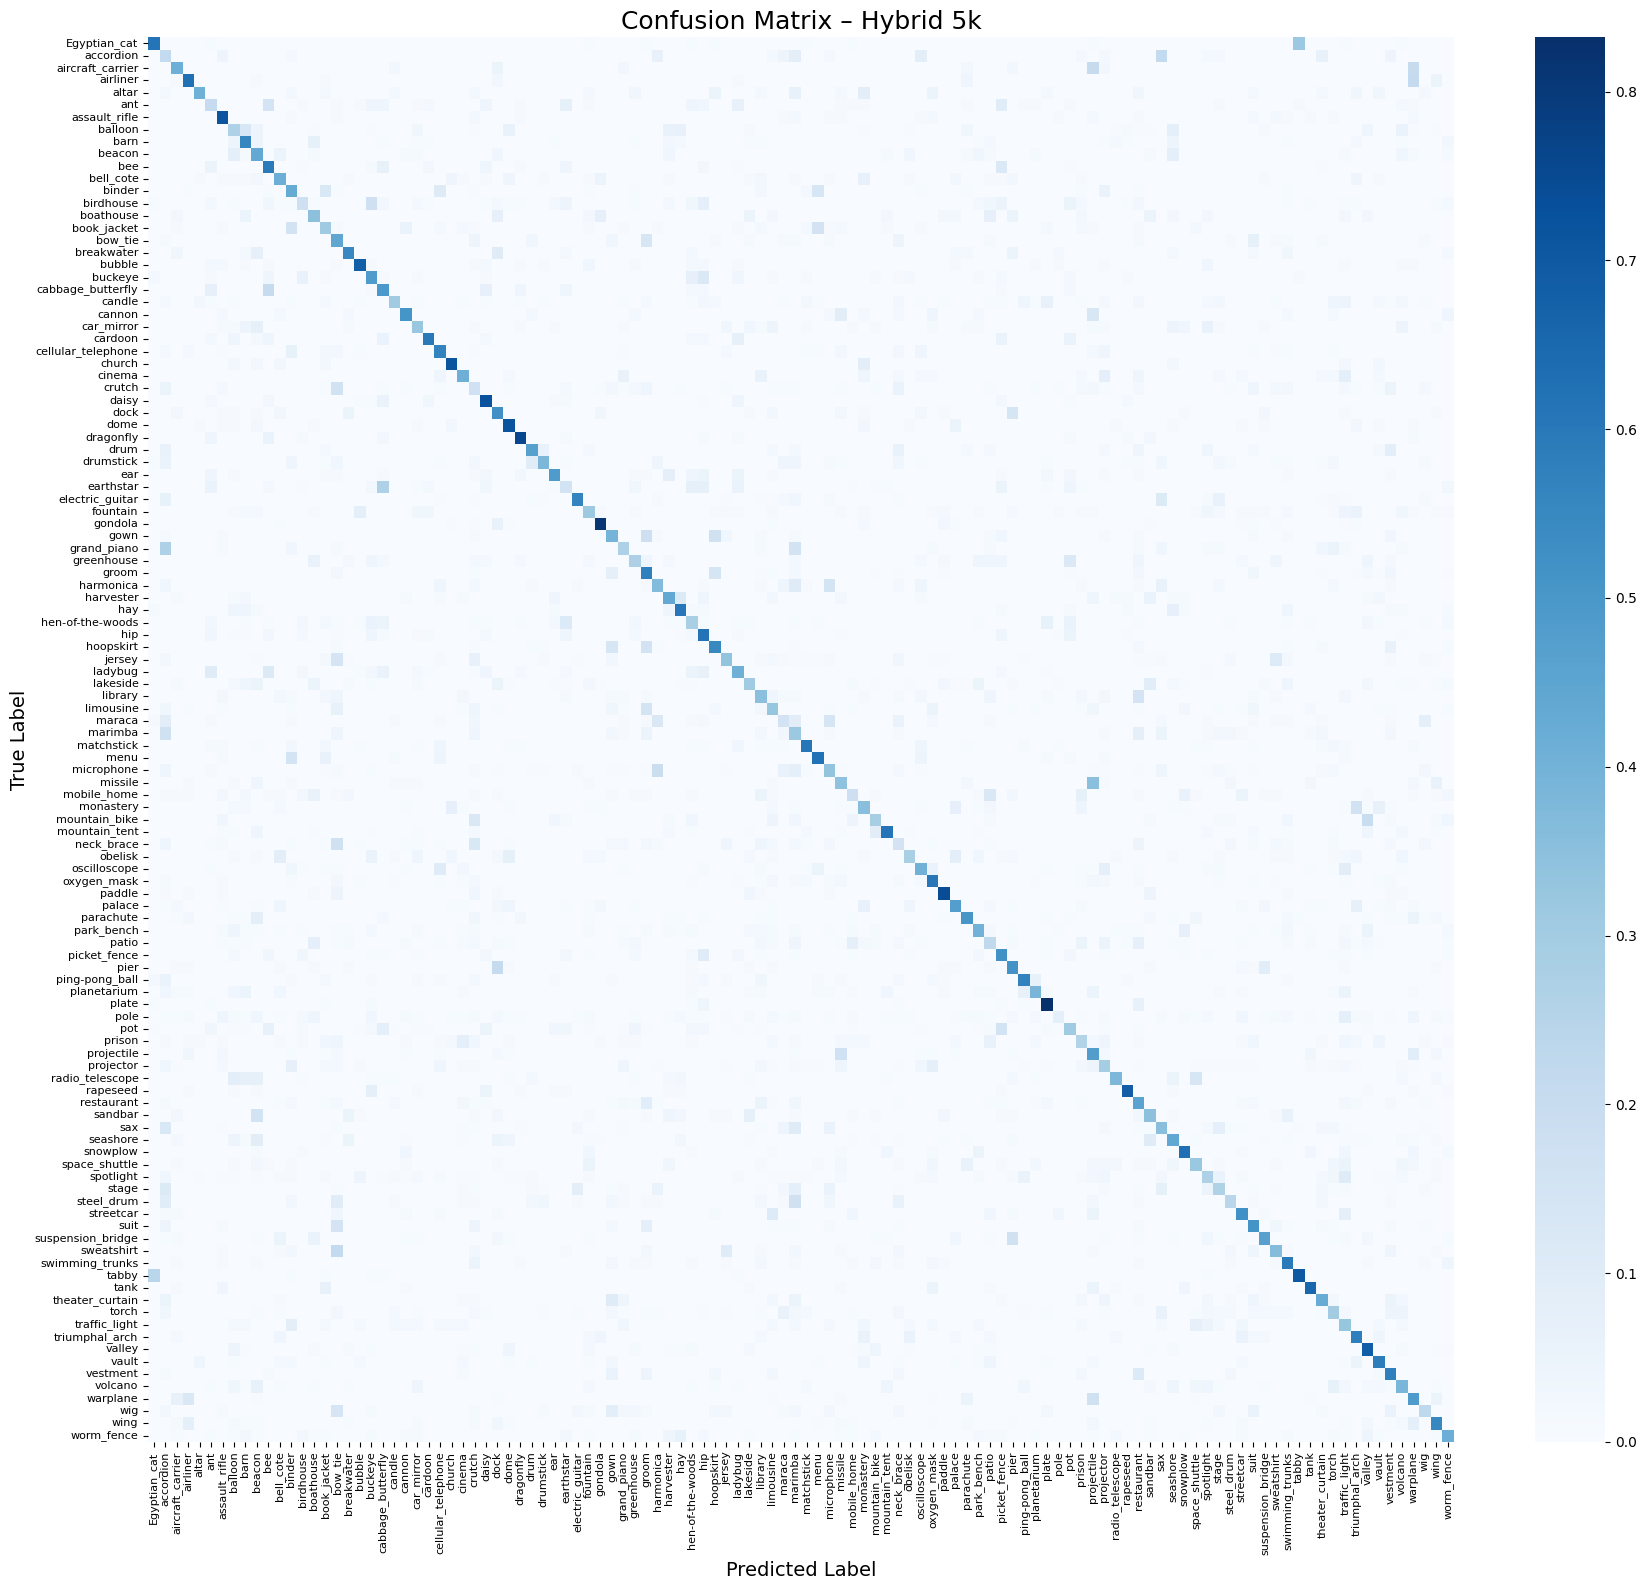

In [ ]:
plot_confusion_matrix_pretty(h5_all_labels, h5_all_preds, class_names, "Confusion Matrix – Hybrid 5k")

In [ ]:
print("📋 Hybrid modell 5k – osztályonkénti metrikák:\n")
h5_df_baseline = export_classification_report(h5_all_labels, h5_all_preds, class_names, "stage_3_resnet18_hybrid_5k")
display(h5_df_baseline.head())

📋 Hybrid modell 5k – osztályonkénti metrikák:


📄 Exportálva: stage_3_resnet18_hybrid_5k


,precision,recall,f1-score,support
Egyptian_cat,0.712000,0.613793,0.659259,145.0
accordion,0.016694,0.212766,0.030960,47.0
aircraft_carrier,0.134454,0.410256,0.202532,39.0
airliner,0.265957,0.625000,0.373134,80.0
altar,0.685714,0.406780,0.510638,59.0


In [ ]:
print_worst_classes(h5_df_baseline, "ResNet18 + Hybrid 5k fej")


📉 ResNet18 + Hybrid 5k fej – Top 10 leggyengébb osztály (F1-score alapján):



,precision,recall,f1-score
accordion,0.016694,0.212766,0.030960
marimba,0.051760,0.316456,0.088968
maraca,0.076087,0.155556,0.102190
crutch,0.096774,0.171429,0.123711
pole,0.407407,0.080882,0.134969
sax,0.092807,0.357143,0.147330
traffic_light,0.100529,0.327586,0.153846
harmonica,0.099462,0.370000,0.156780
neck_brace,0.173554,0.153285,0.162791
earthstar,0.197917,0.157025,0.175115


In [ ]:
# --- GPU memóriahasználat ---
gpu_mem_allocated = torch.cuda.memory_allocated() / (1024 ** 3)
gpu_mem_reserved = torch.cuda.memory_reserved() / (1024 ** 3)

print(f"💾 GPU memória (lefoglalt): {gpu_mem_reserved:.2f} GB")
print(f"💾 GPU memória (használt):  {gpu_mem_allocated:.2f} GB")

💾 GPU memória (lefoglalt): 2.46 GB
💾 GPU memória (használt):  0.62 GB


---

10K

---

[ResNet18-Hybrid-10k] Epoch 1/10 - val: 100%|██████████| 282/282 [00:16<00:00, 17.48it/s]


📊 [ResNet18-Hybrid-10k] Epoch 1: Train loss=3.9237, acc=0.2318 | Val loss=3.5185, acc=0.2806


[ResNet18-Hybrid-10k] Epoch 2/10 - val: 100%|██████████| 282/282 [00:15<00:00, 17.89it/s]


📊 [ResNet18-Hybrid-10k] Epoch 2: Train loss=3.0995, acc=0.4396 | Val loss=3.0631, acc=0.3661


[ResNet18-Hybrid-10k] Epoch 3/10 - val: 100%|██████████| 282/282 [00:15<00:00, 17.75it/s]


...

📊 [ResNet18-Hybrid-10k] Epoch 8: Train loss=0.3264, acc=0.9922 | Val loss=2.3282, acc=0.4815


[ResNet18-Hybrid-10k] Epoch 9/10 - val: 100%|██████████| 282/282 [00:15<00:00, 18.12it/s]


📊 [ResNet18-Hybrid-10k] Epoch 9: Train loss=0.2164, acc=0.9954 | Val loss=2.4075, acc=0.4620


[ResNet18-Hybrid-10k] Epoch 10/10 - val: 100%|██████████| 282/282 [00:15<00:00, 17.85it/s]


📊 [ResNet18-Hybrid-10k] Epoch 10: Train loss=0.1466, acc=0.9973 | Val loss=2.3651, acc=0.4657


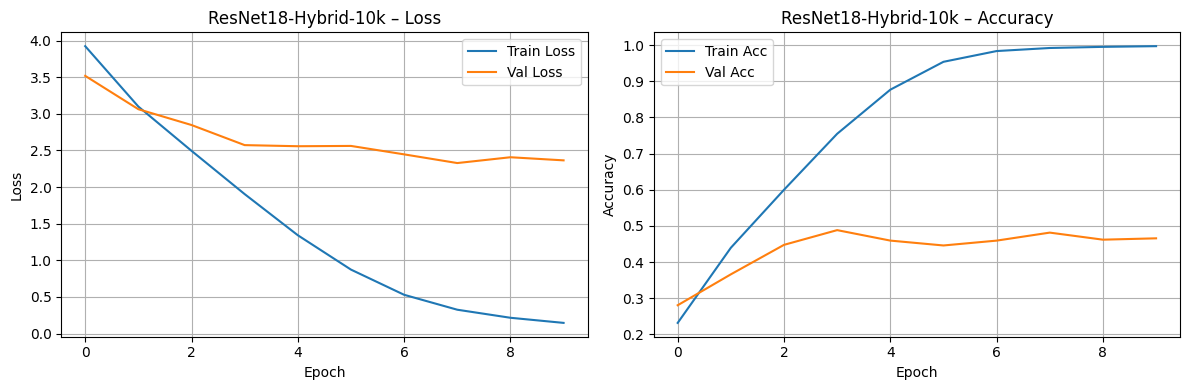

In [ ]:
h10_model_a = ResNet18HybridV2Head(num_classes=114).to(device)
subset_10k = train_subsets["10000"]
h10_model, h10_train_loss_hist, h10_val_loss_hist, h10_train_acc_hist, h10_val_acc_hist = train_model_on_subset(h10_model_a, "ResNet18-Hybrid-10k", subset_10k, num_epochs=10, plot_results=True)

In [ ]:
h10_model.eval()
h10_all_preds, h10_all_labels, h10_all_probs = [], [], []

h10_start_time = time.time()

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="🔍 Hybrid modell 1k – tesztelés"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = h10_model(inputs)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        h10_all_preds.extend(preds.cpu().numpy())
        h10_all_labels.extend(labels.cpu().numpy())
        h10_all_probs.extend(probs.cpu().numpy())

h10_inference_time_baseline = time.time() - h10_start_time

🔍 Hybrid modell 1k – tesztelés: 100%|██████████| 284/284 [00:15<00:00, 18.23it/s]


In [ ]:
h10_metrics_baseline = evaluate_metrics(
    np.array(h10_all_labels), np.array(h10_all_preds), np.array(h10_all_probs),
    "ResNet18 + Hybrid fej 10k", h10_inference_time_baseline
)


🔍 Vizsgálat eredményei (ResNet18 + Hybrid fej 10k – tanítás nélkül):
✅ Top-1 Accuracy:  0.4770
✅ Top-5 Accuracy:  0.7538
🎯 Precision:       0.4507
🎯 Recall:          0.5072
🎯 F1-score:        0.4619
⏱️ Inference time:  15.58 sec


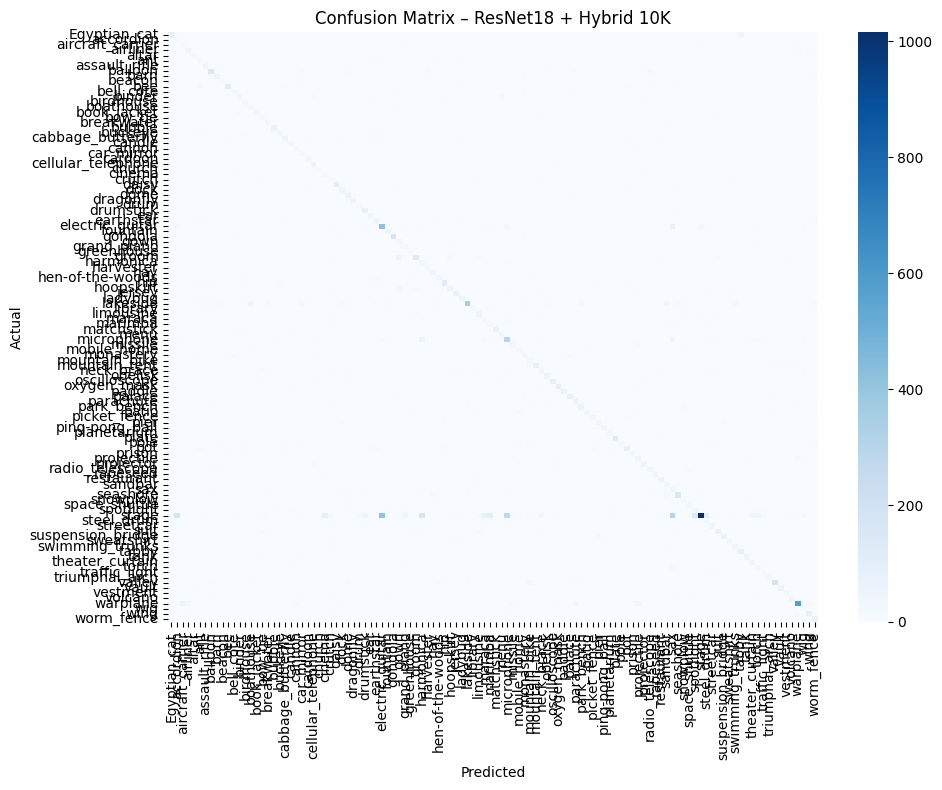

In [ ]:
plot_confusion_matrix(h10_all_labels, h10_all_preds, class_names, "Confusion Matrix – ResNet18 + Hybrid 10K")

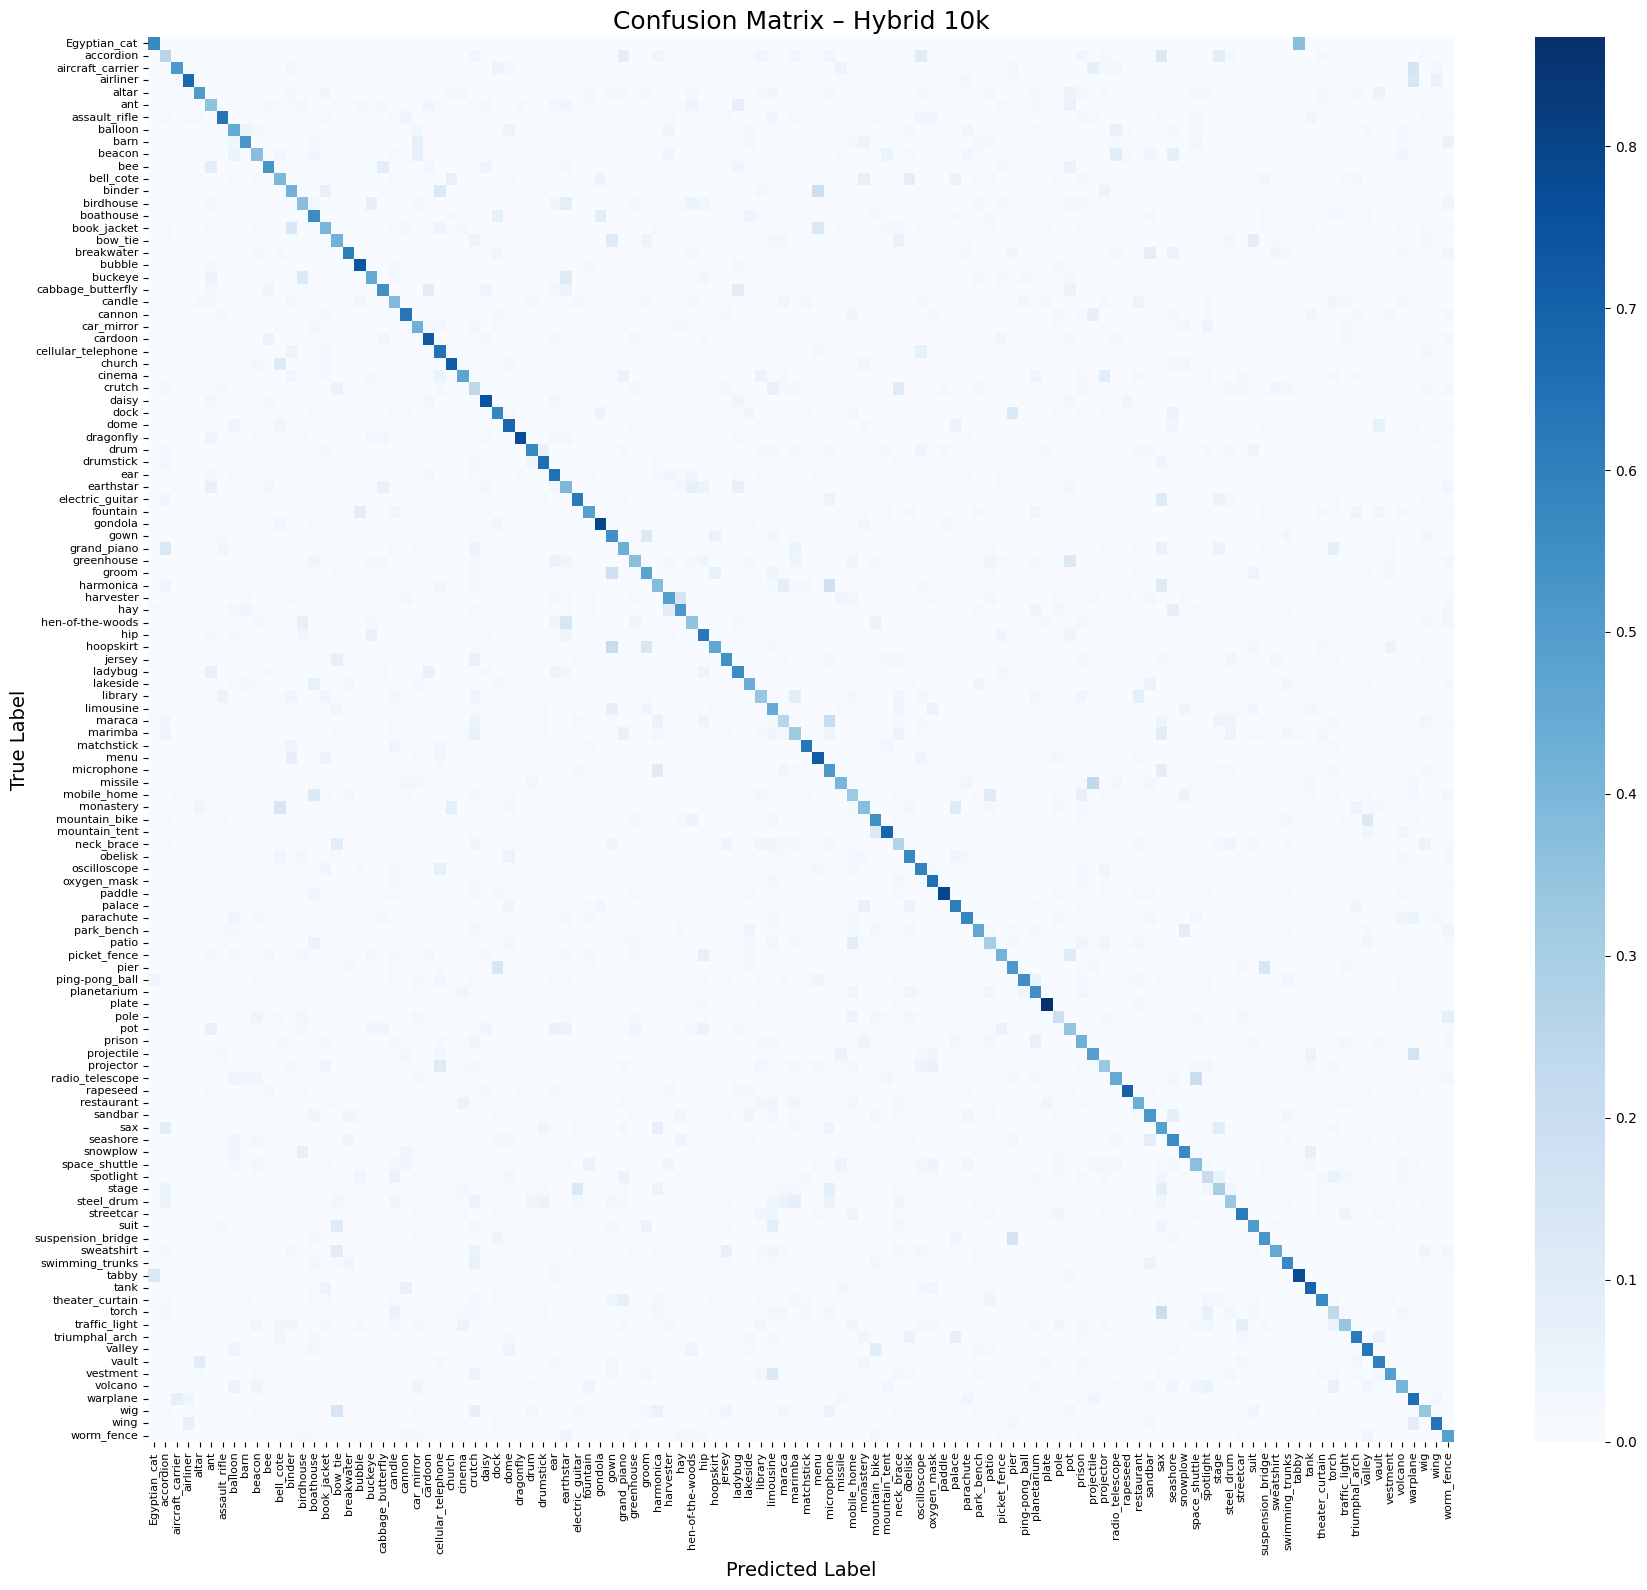

In [ ]:
plot_confusion_matrix_pretty(h10_all_labels, h10_all_preds, class_names, "Confusion Matrix – Hybrid 10k")

In [ ]:
print("📋 Hybrid modell 10k – osztályonkénti metrikák:\n")
h10_df_baseline = export_classification_report(h10_all_labels, h10_all_preds, class_names, "stage_3_resnet18_hybrid_10k")
display(h10_df_baseline.head())

📋 Hybrid modell 10k – osztályonkénti metrikák:


📄 Exportálva: stage_3_resnet18_hybrid_10k


,precision,recall,f1-score,support
Egyptian_cat,0.768519,0.572414,0.656126,145.0
accordion,0.042553,0.255319,0.072948,47.0
aircraft_carrier,0.229885,0.512821,0.317460,39.0
airliner,0.495413,0.675000,0.571429,80.0
altar,0.576923,0.508475,0.540541,59.0


In [ ]:
print_worst_classes(h10_df_baseline, "ResNet18 + Hybrid 10k fej")


📉 ResNet18 + Hybrid 10k fej – Top 10 leggyengébb osztály (F1-score alapján):



,precision,recall,f1-score
accordion,0.042553,0.255319,0.072948
sax,0.093857,0.491071,0.157593
maraca,0.125000,0.255556,0.167883
crutch,0.138122,0.238095,0.174825
marimba,0.125628,0.316456,0.179856
harmonica,0.118750,0.380000,0.180952
torch,0.168750,0.232759,0.195652
steel_drum,0.145078,0.333333,0.202166
spotlight,0.197248,0.212871,0.204762
pole,0.320513,0.183824,0.233645


In [ ]:
# --- GPU memóriahasználat ---
gpu_mem_allocated = torch.cuda.memory_allocated() / (1024 ** 3)
gpu_mem_reserved = torch.cuda.memory_reserved() / (1024 ** 3)

print(f"💾 GPU memória (lefoglalt): {gpu_mem_reserved:.2f} GB")
print(f"💾 GPU memória (használt):  {gpu_mem_allocated:.2f} GB")

💾 GPU memória (lefoglalt): 2.66 GB
💾 GPU memória (használt):  0.72 GB


---

25k

---

[ResNet18-Hybrid-25k] Epoch 1/10 - val: 100%|██████████| 282/282 [00:15<00:00, 18.12it/s]


📊 [ResNet18-Hybrid-25k] Epoch 1: Train loss=3.4917, acc=0.3140 | Val loss=2.8164, acc=0.4243


[ResNet18-Hybrid-25k] Epoch 2/10 - val: 100%|██████████| 282/282 [00:15<00:00, 18.38it/s]


📊 [ResNet18-Hybrid-25k] Epoch 2: Train loss=2.4548, acc=0.5158 | Val loss=2.4907, acc=0.4378


[ResNet18-Hybrid-25k] Epoch 3/10 - val: 100%|██████████| 282/282 [00:15<00:00, 17.95it/s]


...

📊 [ResNet18-Hybrid-25k] Epoch 8: Train loss=0.1412, acc=0.9847 | Val loss=2.0042, acc=0.5289


[ResNet18-Hybrid-25k] Epoch 9/10 - val: 100%|██████████| 282/282 [00:15<00:00, 18.12it/s]


📊 [ResNet18-Hybrid-25k] Epoch 9: Train loss=0.0937, acc=0.9892 | Val loss=1.9949, acc=0.5358


[ResNet18-Hybrid-25k] Epoch 10/10 - val: 100%|██████████| 282/282 [00:15<00:00, 17.91it/s]


📊 [ResNet18-Hybrid-25k] Epoch 10: Train loss=0.0771, acc=0.9903 | Val loss=2.1270, acc=0.5119


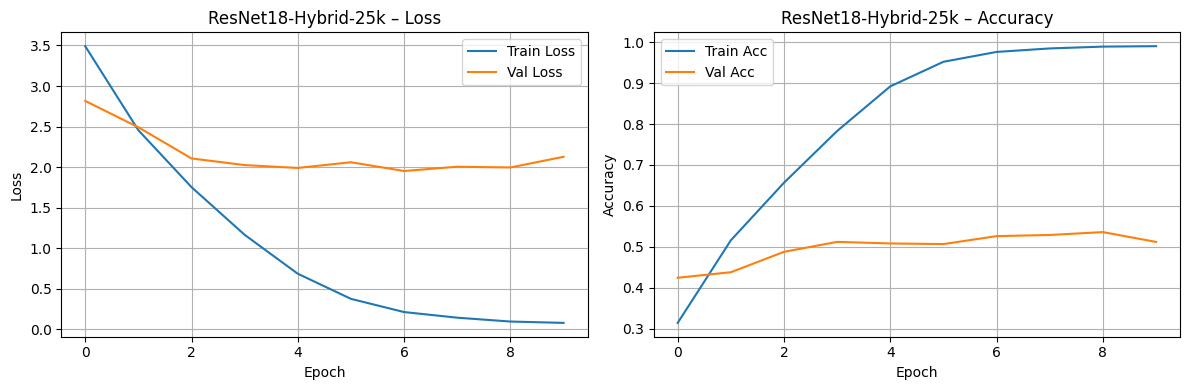

In [ ]:
h25_model_a = ResNet18HybridV2Head(num_classes=114).to(device)
subset_25k = train_subsets["25000"]
h25_model, h25_train_loss_hist, h25_val_loss_hist, h25_train_acc_hist, h25_val_acc_hist = train_model_on_subset(h25_model_a, "ResNet18-Hybrid-25k", subset_25k, num_epochs=10, plot_results=True)

In [ ]:
h25_model.eval()
h25_all_preds, h25_all_labels, h25_all_probs = [], [], []

h25_start_time = time.time()

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="🔍 Hybrid modell 25k – tesztelés"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = h25_model(inputs)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        h25_all_preds.extend(preds.cpu().numpy())
        h25_all_labels.extend(labels.cpu().numpy())
        h25_all_probs.extend(probs.cpu().numpy())

h25_inference_time_baseline = time.time() - h25_start_time

🔍 Hybrid modell 25k – tesztelés: 100%|██████████| 284/284 [00:15<00:00, 17.94it/s]


In [ ]:
h25_metrics_baseline = evaluate_metrics(
    np.array(h25_all_labels), np.array(h25_all_preds), np.array(h25_all_probs),
    "ResNet18 + Hybrid fej 25k", h25_inference_time_baseline
)


🔍 Vizsgálat eredményei (ResNet18 + Hybrid fej 25k – tanítás nélkül):
✅ Top-1 Accuracy:  0.5196
✅ Top-5 Accuracy:  0.7984
🎯 Precision:       0.5002
🎯 Recall:          0.5679
🎯 F1-score:        0.5123
⏱️ Inference time:  15.83 sec


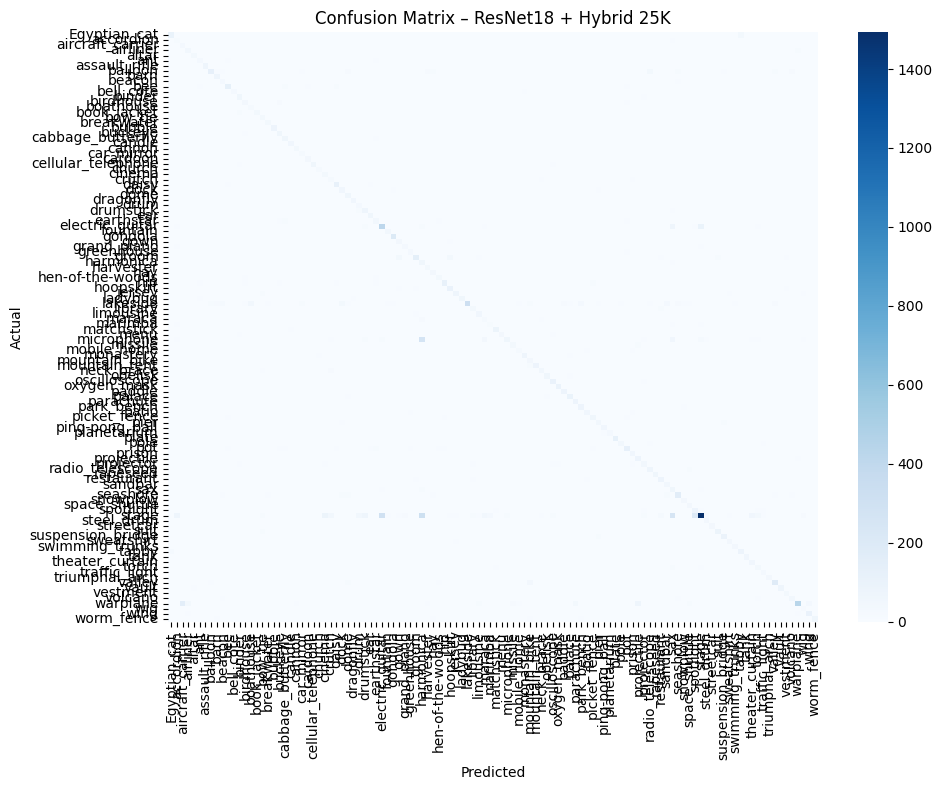

In [ ]:
plot_confusion_matrix(h25_all_labels, h25_all_preds, class_names, "Confusion Matrix – ResNet18 + Hybrid 25K")

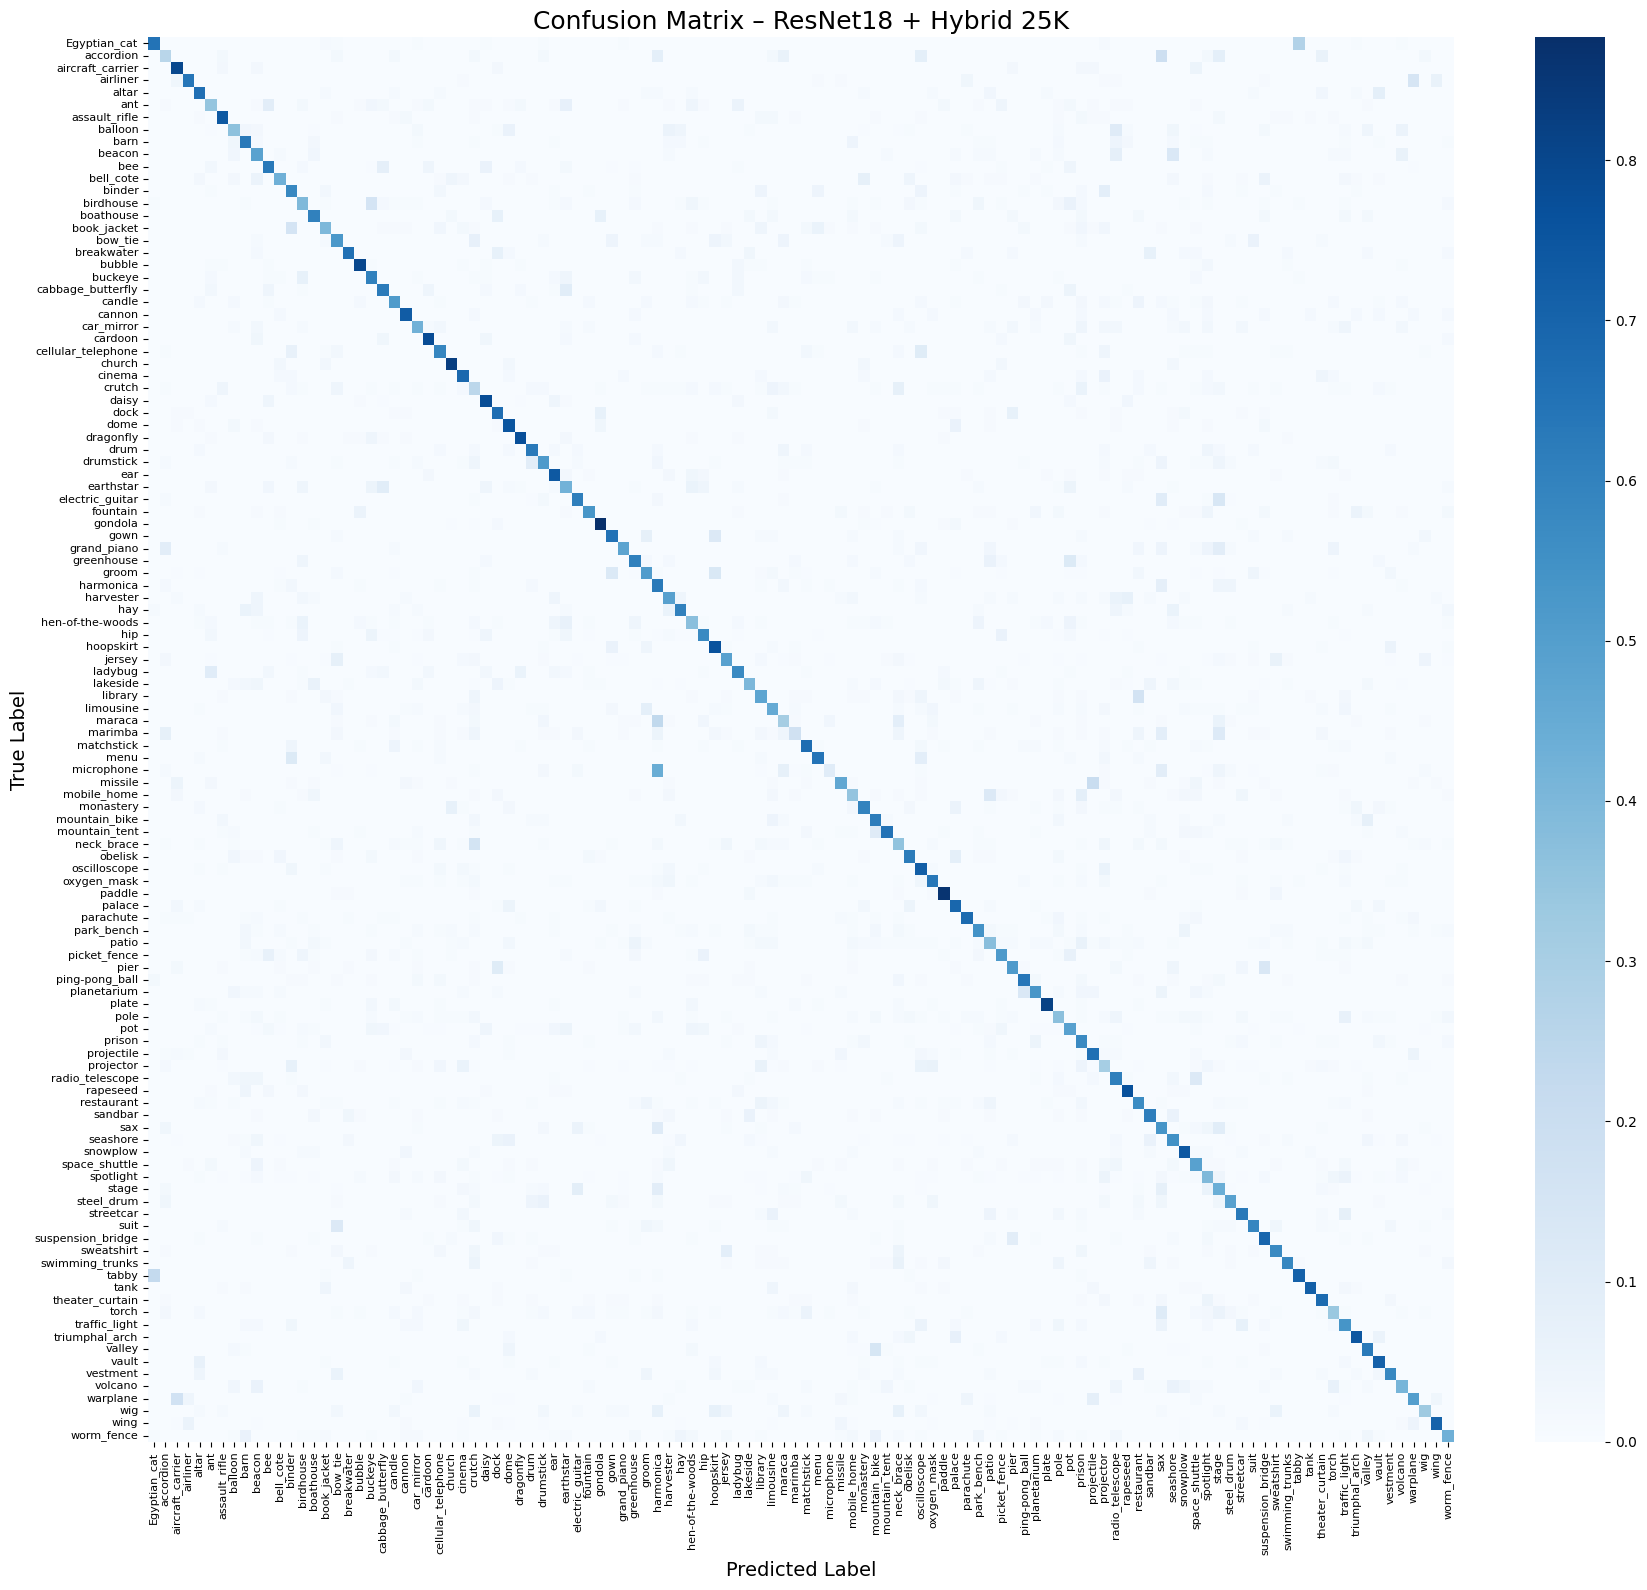

In [ ]:
plot_confusion_matrix_pretty(h25_all_labels, h25_all_preds, class_names, "Confusion Matrix – ResNet18 + Hybrid 25K")

In [ ]:
print("📋 Hybrid modell 1k – osztályonkénti metrikák:\n")
h25_df_baseline = export_classification_report(h25_all_labels, h25_all_preds, class_names, "stage_3_resnet18_hybrid_25k")
display(h25_df_baseline.head())


📋 Hybrid modell 1k – osztályonkénti metrikák:


📄 Exportálva: stage_3_resnet18_hybrid_25k


,precision,recall,f1-score,support
Egyptian_cat,0.758065,0.648276,0.698885,145.0
accordion,0.082192,0.255319,0.124352,47.0
aircraft_carrier,0.150485,0.794872,0.253061,39.0
airliner,0.504950,0.637500,0.563536,80.0
altar,0.475610,0.661017,0.553191,59.0


In [ ]:
print_worst_classes(h25_df_baseline, "ResNet18 + Hybrid 25k fej")


📉 ResNet18 + Hybrid 25k fej – Top 10 leggyengébb osztály (F1-score alapján):



,precision,recall,f1-score
accordion,0.082192,0.255319,0.124352
harmonica,0.083223,0.630000,0.147025
crutch,0.131313,0.247619,0.171617
microphone,0.701149,0.102349,0.178624
marimba,0.181818,0.177215,0.179487
sax,0.116279,0.535714,0.191083
maraca,0.165680,0.311111,0.216216
aircraft_carrier,0.150485,0.794872,0.253061
spotlight,0.224719,0.396040,0.286738
projector,0.292683,0.305732,0.299065


In [ ]:
# --- GPU memóriahasználat ---
gpu_mem_allocated = torch.cuda.memory_allocated() / (1024 ** 3)
gpu_mem_reserved = torch.cuda.memory_reserved() / (1024 ** 3)

print(f"💾 GPU memória (lefoglalt): {gpu_mem_reserved:.2f} GB")
print(f"💾 GPU memória (használt):  {gpu_mem_allocated:.2f} GB")

💾 GPU memória (lefoglalt): 2.67 GB
💾 GPU memória (használt):  0.82 GB


---

Összesítő statisztikák

---

<ipython-input-76-91fdd9435787>:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


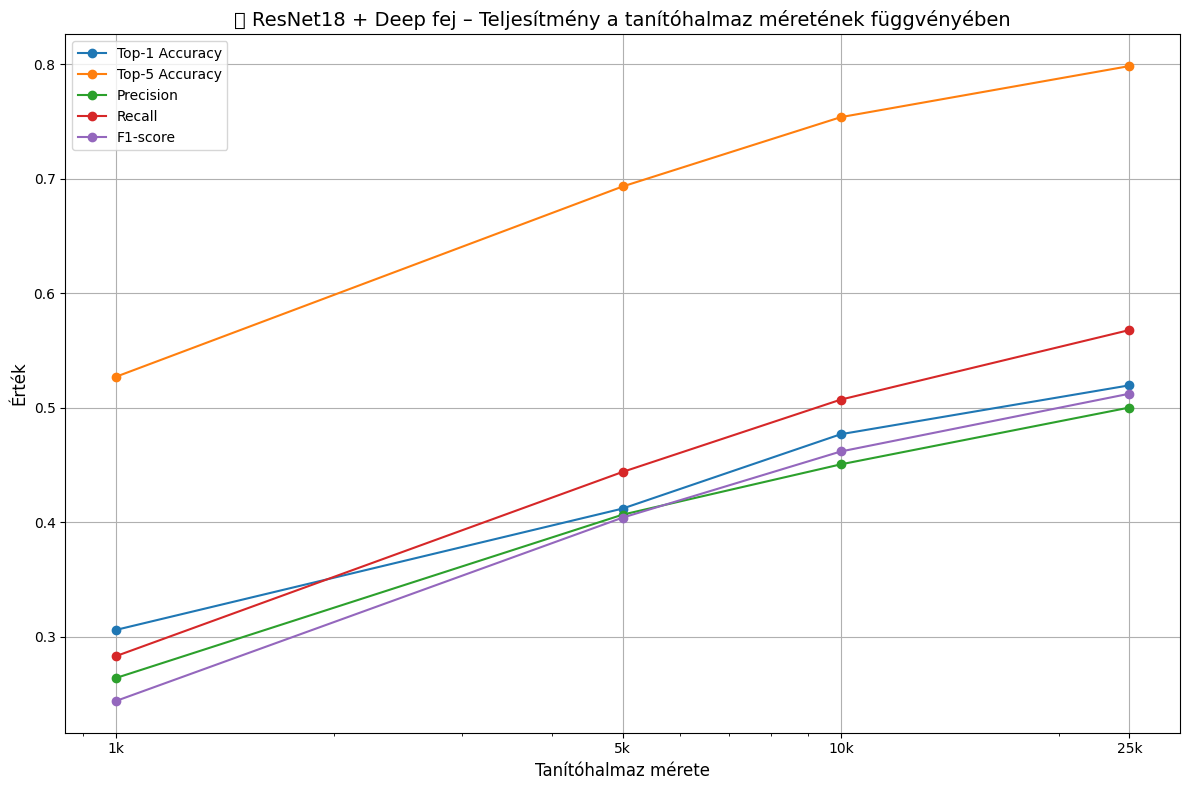

In [ ]:
# --- 📊 Összesített metrikák begyűjtése ---
metric_data = {
    "Train Size": [1000, 5000, 10000, 25000],
    "Top-1 Accuracy": [
        h1_metrics_baseline["top1"],
        h5_metrics_baseline["top1"],
        h10_metrics_baseline["top1"],
        h25_metrics_baseline["top1"]
    ],
    "Top-5 Accuracy": [
        h1_metrics_baseline["top5"],
        h5_metrics_baseline["top5"],
        h10_metrics_baseline["top5"],
        h25_metrics_baseline["top5"]
    ],
    "Precision": [
        h1_metrics_baseline["precision"],
        h5_metrics_baseline["precision"],
        h10_metrics_baseline["precision"],
        h25_metrics_baseline["precision"]
    ],
    "Recall": [
        h1_metrics_baseline["recall"],
        h5_metrics_baseline["recall"],
        h10_metrics_baseline["recall"],
        h25_metrics_baseline["recall"]
    ],
    "F1-score": [
        h1_metrics_baseline["f1"],
        h5_metrics_baseline["f1"],
        h10_metrics_baseline["f1"],
        h25_metrics_baseline["f1"]
    ]
}

# --- 📊 DataFrame-be rendezés ---
df_metrics = pd.DataFrame(metric_data)

# --- 📈 Grafikon rajzolása ---
plt.figure(figsize=(12, 8))
for metric in ["Top-1 Accuracy", "Top-5 Accuracy", "Precision", "Recall", "F1-score"]:
    plt.plot(df_metrics["Train Size"], df_metrics[metric], marker='o', label=metric)

plt.title("📊 ResNet18 + Deep fej – Teljesítmény a tanítóhalmaz méretének függvényében", fontsize=14)
plt.xlabel("Tanítóhalmaz mérete", fontsize=12)
plt.ylabel("Érték", fontsize=12)
plt.xscale("log")
plt.xticks(df_metrics["Train Size"], labels=[f"{int(x/1000)}k" for x in df_metrics["Train Size"]])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

<ipython-input-77-627ca277277e>:41: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-77-627ca277277e>:41: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


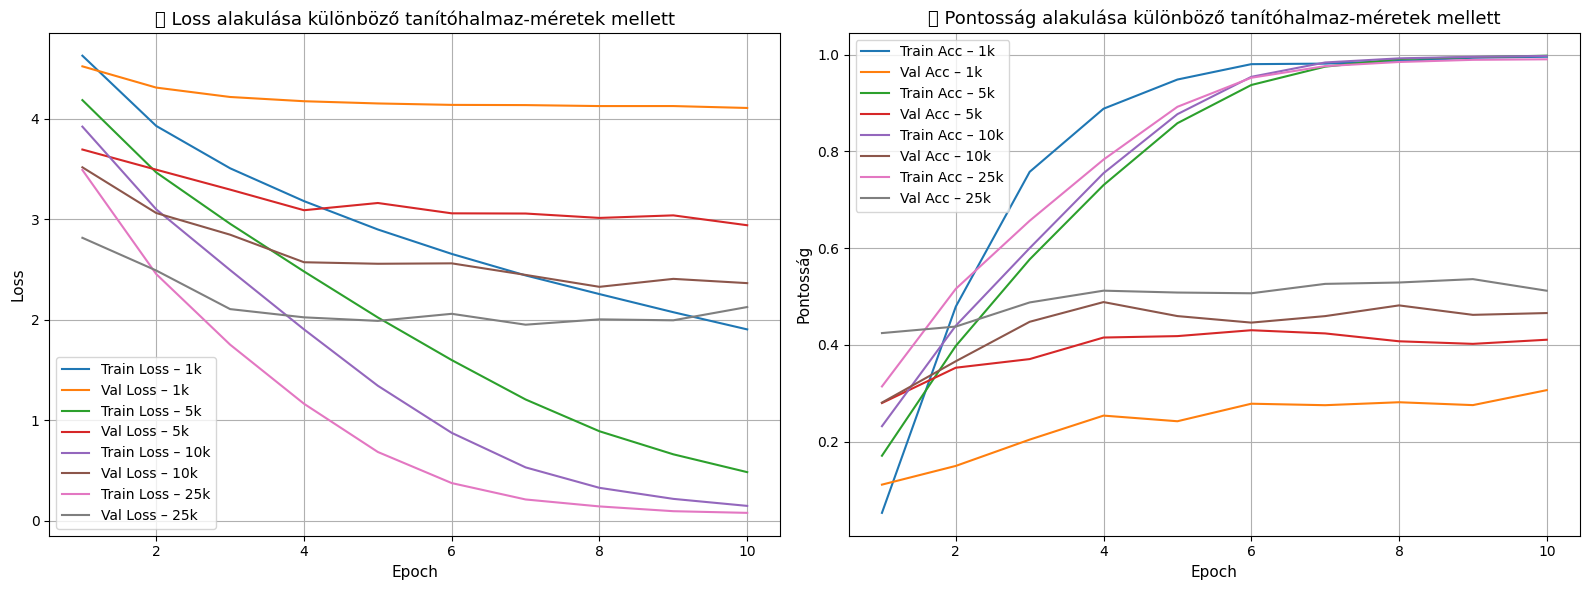

In [ ]:
import matplotlib.pyplot as plt

# --- Epoch tengely ---
epochs = list(range(1, len(h1_train_loss_hist) + 1))

# --- 🎨 Ábra beállítás ---
plt.figure(figsize=(16, 6))

# --- 📉 Loss görbék ---
plt.subplot(1, 2, 1)
plt.plot(epochs, h1_train_loss_hist, label="Train Loss – 1k")
plt.plot(epochs, h1_val_loss_hist, label="Val Loss – 1k")
plt.plot(epochs, h5_train_loss_hist, label="Train Loss – 5k")
plt.plot(epochs, h5_val_loss_hist, label="Val Loss – 5k")
plt.plot(epochs, h10_train_loss_hist, label="Train Loss – 10k")
plt.plot(epochs, h10_val_loss_hist, label="Val Loss – 10k")
plt.plot(epochs, h25_train_loss_hist, label="Train Loss – 25k")
plt.plot(epochs, h25_val_loss_hist, label="Val Loss – 25k")
plt.title("📉 Loss alakulása különböző tanítóhalmaz-méretek mellett", fontsize=13)
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Loss", fontsize=11)
plt.legend()
plt.grid(True)

# --- 📈 Accuracy görbék ---
plt.subplot(1, 2, 2)
plt.plot(epochs, h1_train_acc_hist, label="Train Acc – 1k")
plt.plot(epochs, h1_val_acc_hist, label="Val Acc – 1k")
plt.plot(epochs, h5_train_acc_hist, label="Train Acc – 5k")
plt.plot(epochs, h5_val_acc_hist, label="Val Acc – 5k")
plt.plot(epochs, h10_train_acc_hist, label="Train Acc – 10k")
plt.plot(epochs, h10_val_acc_hist, label="Val Acc – 10k")
plt.plot(epochs, h25_train_acc_hist, label="Train Acc – 25k")
plt.plot(epochs, h25_val_acc_hist, label="Val Acc – 25k")
plt.title("📈 Pontosság alakulása különböző tanítóhalmaz-méretek mellett", fontsize=13)
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Pontosság", fontsize=11)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

<ipython-input-78-319ec352b43a>:25: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


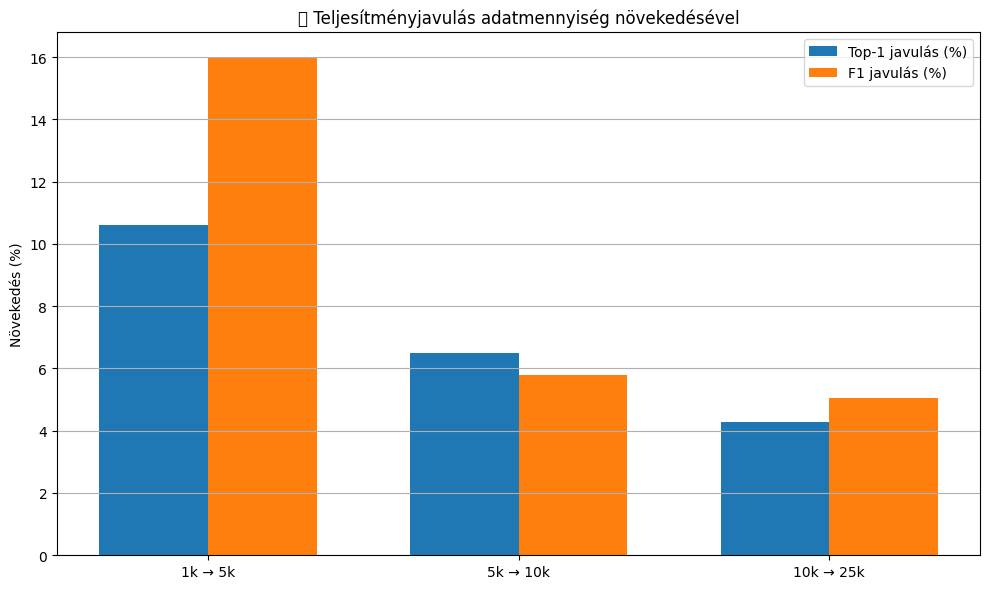

In [ ]:
# 4️⃣ Metrikák arányos növekedése (pl. megtérülés-elemzés)
import matplotlib.pyplot as plt
import numpy as np

train_sizes = [1000, 5000, 10000, 25000]
top1s  = [h1_metrics_baseline["top1"], h5_metrics_baseline["top1"], h10_metrics_baseline["top1"], h25_metrics_baseline["top1"]]
f1s    = [h1_metrics_baseline["f1"],   h5_metrics_baseline["f1"],   h10_metrics_baseline["f1"],   h25_metrics_baseline["f1"]]

top1_gains = [100 * (b - a) for a, b in zip(top1s[:-1], top1s[1:])]
f1_gains   = [100 * (b - a) for a, b in zip(f1s[:-1],   f1s[1:])]

labels = ["1k → 5k", "5k → 10k", "10k → 25k"]
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, top1_gains, width, label='Top-1 javulás (%)')
plt.bar(x + width/2, f1_gains, width, label='F1 javulás (%)')

plt.ylabel('Növekedés (%)')
plt.title('📈 Teljesítményjavulás adatmennyiség növekedésével')
plt.xticks(x, labels)
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
def plot_confusion_matrix_pretty(y_true, y_pred, class_names, title="Confusion Matrix", show=True, small=False):
    """
    Szépített Confusion Matrix.
    - show=False esetén subplotba ágyazható
    - small=True esetén eltünteti a címkéket és kisebb betűket használ
    """
    cm = confusion_matrix(y_true, y_pred, normalize='true')

    if show:
        figsize = (12, 10) if small else (18, 16)
        plt.figure(figsize=figsize)

    sns.heatmap(
        cm,
        annot=False,
        cmap='Blues',
        cbar=True,
        xticklabels=class_names if not small else False,
        yticklabels=class_names if not small else False
    )

    plt.title(title, fontsize=12 if small else 18)
    if not small:
        plt.xlabel('Predicted Label', fontsize=14)
        plt.ylabel('True Label', fontsize=14)
        plt.xticks(rotation=90, fontsize=8)
        plt.yticks(fontsize=8)
    else:
        plt.xlabel("")
        plt.ylabel("")
        plt.xticks([])
        plt.yticks([])

    if show:
        plt.tight_layout()
        plt.show()

<ipython-input-81-7248e47c0db2>:19: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.95])
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


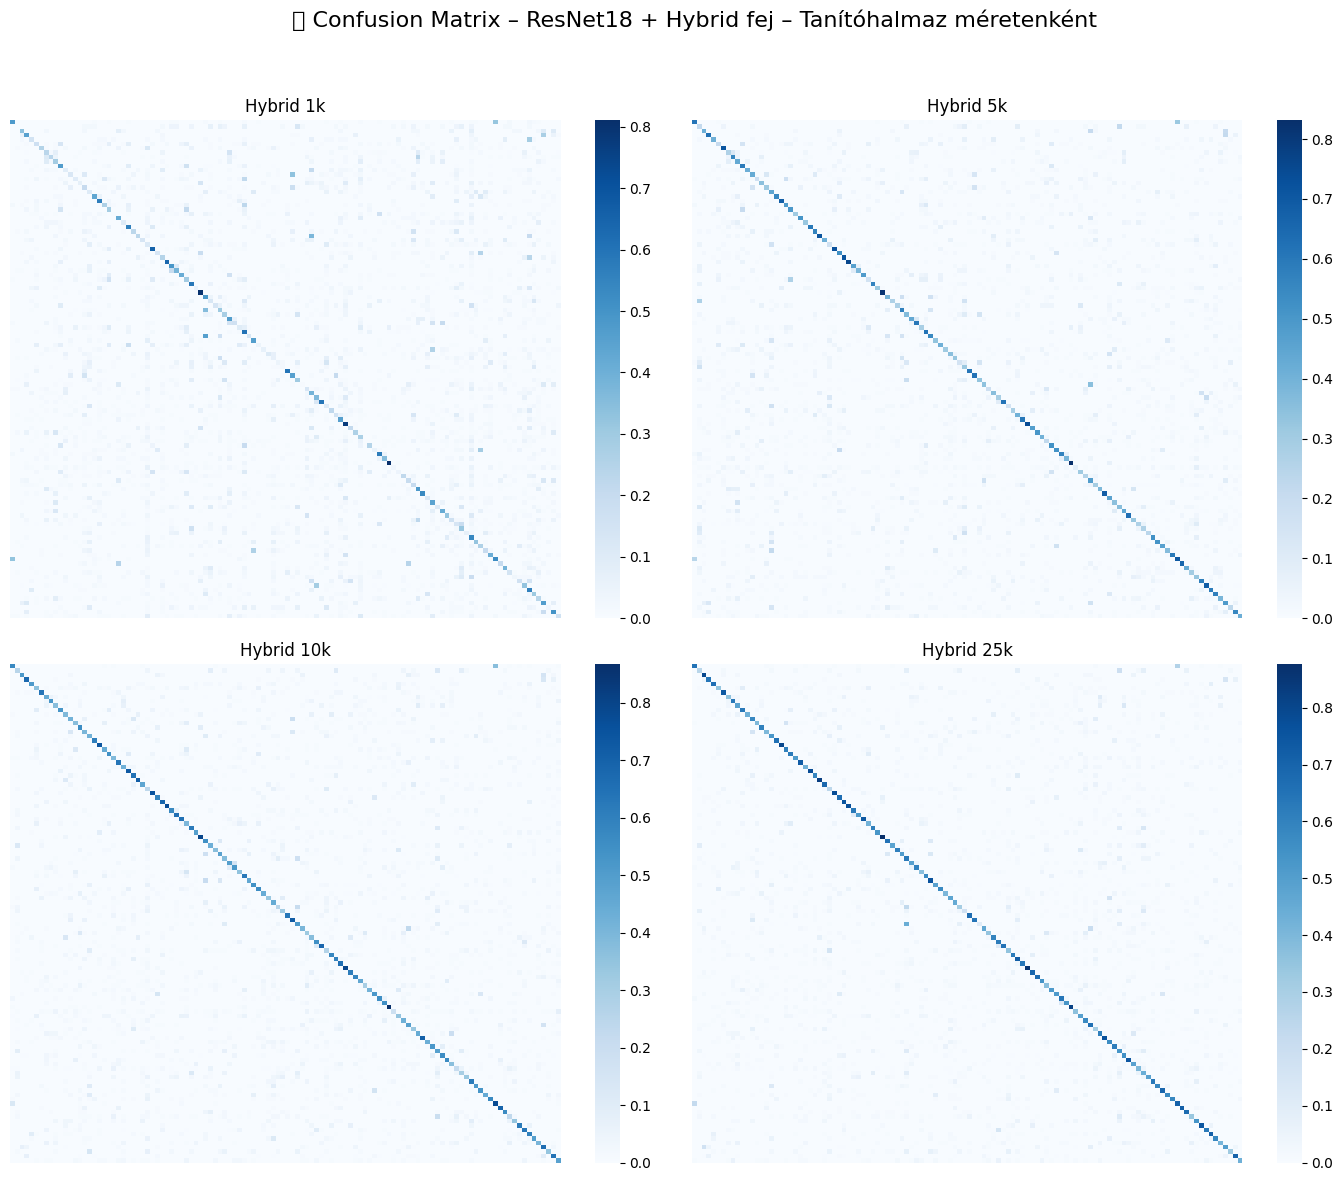

In [ ]:
# 5️⃣ Confusion Matrix összehasonlító ábra – szépített 2x2-ben, kicsiben
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Egyedi subplotokba ágyazás
plt.sca(axes[0, 0])
plot_confusion_matrix_pretty(h1_all_labels, h1_all_preds, class_names, "Hybrid 1k", show=False, small=True)

plt.sca(axes[0, 1])
plot_confusion_matrix_pretty(h5_all_labels, h5_all_preds, class_names, "Hybrid 5k", show=False, small=True)

plt.sca(axes[1, 0])
plot_confusion_matrix_pretty(h10_all_labels, h10_all_preds, class_names, "Hybrid 10k", show=False, small=True)

plt.sca(axes[1, 1])
plot_confusion_matrix_pretty(h25_all_labels, h25_all_preds, class_names, "Hybrid 25k", show=False, small=True)

# Közös cím
plt.suptitle("📊 Confusion Matrix – ResNet18 + Hybrid fej – Tanítóhalmaz méretenként", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
# 6️⃣ Leggyengébb osztályok F1-score alakulása
def extract_worst_f1(df, top_n=5):
    df = df.reset_index().rename(columns={"index": "class"})
    return df.sort_values("f1-score").head(top_n)[["class", "f1-score"]].reset_index(drop=True)

worst_1k  = extract_worst_f1(h1_df_baseline)
worst_5k  = extract_worst_f1(h5_df_baseline)
worst_10k = extract_worst_f1(h10_df_baseline)
worst_25k = extract_worst_f1(h25_df_baseline)

# Keresztösszehasonlítás (az 1k legrosszabb osztályait követjük végig)
common_classes = worst_1k["class"].tolist()

rows = []
for cls in common_classes:
    row = {"class": cls}
    for label, df in [("1k", h1_df_baseline), ("5k", h5_df_baseline), ("10k", h10_df_baseline), ("25k", h25_df_baseline)]:
        df_ = df.reset_index().rename(columns={"index": "class"})  # 🧠 Itt a javítás!
        f1 = df_[df_["class"] == cls]["f1-score"].values[0] if cls in df_["class"].values else np.nan
        row[f"F1-{label}"] = f1
    rows.append(row)

import pandas as pd
df_worst = pd.DataFrame(rows)
print("📋 Leggyengébb osztályok alakulása F1-score alapján:")
display(df_worst)

📋 Leggyengébb osztályok alakulása F1-score alapján:


,class,F1-1k,F1-5k,F1-10k,F1-25k
0,accordion,0.000000,0.030960,0.072948,0.124352
1,patio,0.000000,0.253968,0.353909,0.404494
2,candle,0.016000,0.412121,0.356846,0.513514
3,missile,0.022222,0.290155,0.381503,0.455090
4,wig,0.026316,0.188235,0.265193,0.317241


<ipython-input-84-f883430f25fa>:36: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


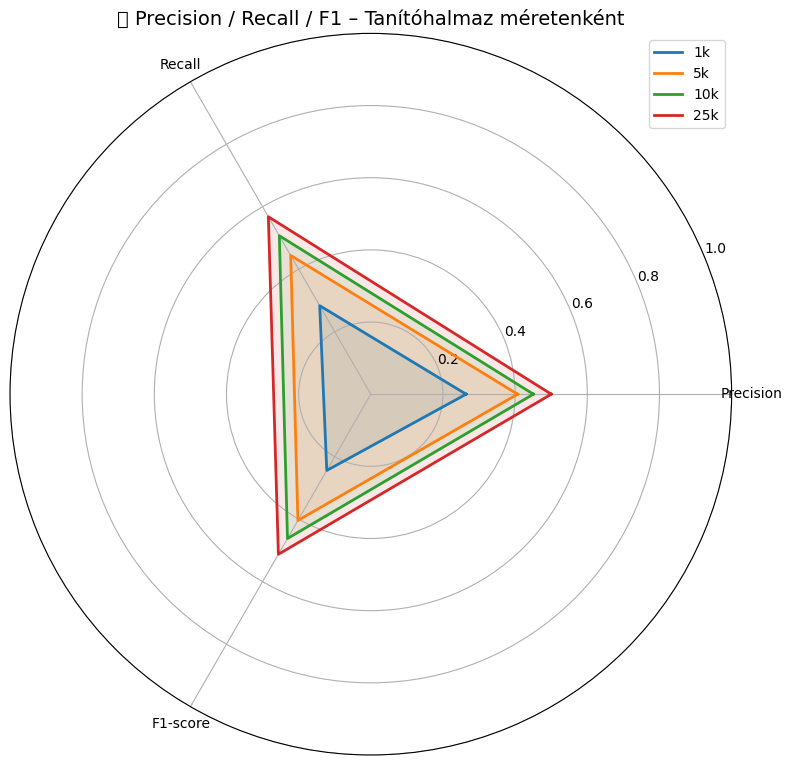

In [ ]:
# 7️⃣ Radar chart – Precision / Recall / F1 különböző méreteknél
import numpy as np
import matplotlib.pyplot as plt

labels = ["Precision", "Recall", "F1-score"]
metrics_1k  = [h1_metrics_baseline["precision"],  h1_metrics_baseline["recall"],  h1_metrics_baseline["f1"]]
metrics_5k  = [h5_metrics_baseline["precision"],  h5_metrics_baseline["recall"],  h5_metrics_baseline["f1"]]
metrics_10k = [h10_metrics_baseline["precision"], h10_metrics_baseline["recall"], h10_metrics_baseline["f1"]]
metrics_25k = [h25_metrics_baseline["precision"], h25_metrics_baseline["recall"], h25_metrics_baseline["f1"]]

# Radar plot setup
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
metrics_1k  += [metrics_1k[0]]
metrics_5k  += [metrics_5k[0]]
metrics_10k += [metrics_10k[0]]
metrics_25k += [metrics_25k[0]]
angles += [angles[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.plot(angles, metrics_1k, label="1k", linewidth=2)
ax.plot(angles, metrics_5k, label="5k", linewidth=2)
ax.plot(angles, metrics_10k, label="10k", linewidth=2)
ax.plot(angles, metrics_25k, label="25k", linewidth=2)

ax.fill(angles, metrics_1k, alpha=0.1)
ax.fill(angles, metrics_5k, alpha=0.1)
ax.fill(angles, metrics_10k, alpha=0.1)
ax.fill(angles, metrics_25k, alpha=0.1)

ax.set_title("📊 Precision / Recall / F1 – Tanítóhalmaz méretenként", size=14)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_ylim(0, 1)
ax.grid(True)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()